# 1 良率分類與分析（Yield Classification and Analysis）

In [1]:
# 資料讀取
import pandas as pd

data_path = r"c:\Users\allen\OneDrive\Desktop\研究所\製造\secom\secom.data"
label_path = r"c:\Users\allen\OneDrive\Desktop\研究所\製造\secom\secom_labels.data"

X = pd.read_csv(data_path, sep=r"\s+", header=None)
y = pd.read_csv(label_path, sep=r"\s+", header=None)

y.columns = ["label", "date"]

df = pd.concat([X, y["label"]], axis=1)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,label
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


資料集形狀: (1567, 591)
樣本數: 1567
變數數量: 590

類別分布:
label
-1    1463
 1     104
Name: count, dtype: int64

類別比例:
label
-1    0.933631
 1    0.066369
Name: proportion, dtype: float64


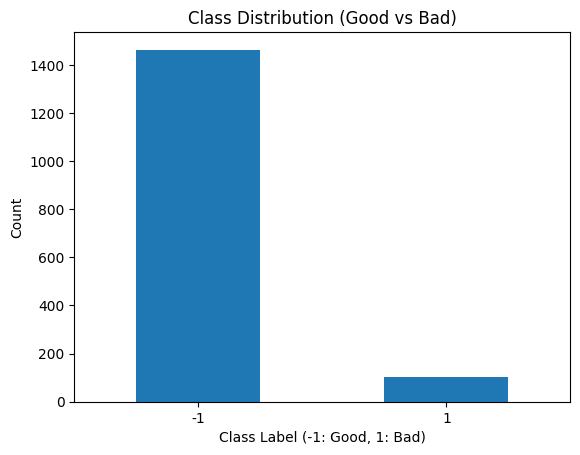

In [2]:
import matplotlib.pyplot as plt

# 基本資訊
print("資料集形狀:", df.shape)

# 樣本數與變數數量
n_samples = df.shape[0]
n_features = df.shape[1] - 1

print(f"樣本數: {n_samples}")
print(f"變數數量: {n_features}")

# 類別分布
class_counts = df["label"].value_counts().sort_index()
print("\n類別分布:")
print(class_counts)

# 類別比例
class_ratio = df["label"].value_counts(normalize=True).sort_index()
print("\n類別比例:")
print(class_ratio)

# 長條圖
plt.figure()
class_counts.plot(kind='bar')

plt.title("Class Distribution (Good vs Bad)")
plt.xlabel("Class Label (-1: Good, 1: Bad)")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.show()

## 1.1 資料摘要結果

- 本資料集共有 **1567 筆樣本**，包含 **590 個感測器變數**與 1 個品質標籤。
- 目標變數為二元分類：
  - **-1：良品**
  - **1：不良品**

### 類別分布

由分析結果可觀察到：
- 大多數樣本為良品
- 不良品比例極低

顯示此資料集具有 **高度類別不平衡** 的特性。

### 初步觀察與問題

1. **高維度資料**
   - 感測器變數多達 590 個，可能存在冗餘或無效特徵

2. **類別不平衡問題**
   - 不良品樣本比例過低，可能導致模型偏向預測良品

3. **後續處理必要性**
   - 需進一步檢查缺失值、異常值與冗餘特徵，並考慮類別不平衡對模型的影響

In [3]:
# 檢查重複樣本
duplicate_count = df.duplicated().sum()
print("重複樣本數:", duplicate_count)

重複樣本數: 0


### 重複樣本檢查

由檢查結果可得，資料中重複樣本數為 **0 筆**。

如果有重複樣本，沒有刪除會使得模型學習到重複資訊而產生偏差。

In [4]:
# 計算每個欄位的缺失比例
missing_ratio = df.isnull().mean()

# 排序
missing_ratio_sorted = missing_ratio.sort_values(ascending=False)

# 顯示前20個缺失最多的欄位
missing_ratio_sorted.head(20)

292    0.911934
293    0.911934
157    0.911934
158    0.911934
220    0.855775
358    0.855775
85     0.855775
492    0.855775
382    0.649649
384    0.649649
244    0.649649
111    0.649649
516    0.649649
517    0.649649
110    0.649649
246    0.649649
245    0.649649
383    0.649649
109    0.649649
518    0.649649
dtype: float64

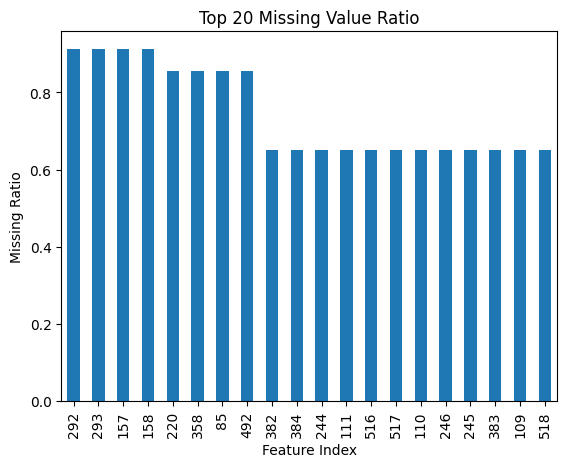

In [5]:
import matplotlib.pyplot as plt

plt.figure()
missing_ratio_sorted.head(20).plot(kind='bar')

plt.title("Top 20 Missing Value Ratio")
plt.ylabel("Missing Ratio")
plt.xlabel("Feature Index")

plt.show()

### 缺失值分析

由結果可觀察到，本資料集存在大量缺失值，且部分變數的缺失比例相當高。

為確保資料品質，本研究採取以下策略：

1. **刪除高缺失比例欄位**
   - 若某欄位缺失比例過高，則將其移除
   - 理由：過多缺失值會降低模型可靠性，且補值可能導致偏差

2. **填補剩餘缺失值**
   - 對其餘欄位採用中位數進行填補
   - 理由：中位數對極端值較不敏感，較適合處理製程資料

In [6]:
# 將特徵與標籤分開
X = df.drop(columns=["label"]).copy()
y = df["label"].copy()

# 先移除前面檢查到的低變異欄位
variance = X.var()
low_variance_threshold = 1e-5
low_variance_cols = variance[variance < low_variance_threshold].index
X = X.drop(columns=low_variance_cols, errors="ignore")
print("低變異欄位數:", len(low_variance_cols))

# 計算缺失比例
missing_ratio = X.isnull().mean()

# 找出缺失比例 > 50% 的欄位
threshold = 0.5
cols_to_drop = missing_ratio[missing_ratio > threshold].index

# 刪除高缺失欄位
X = X.drop(columns=cols_to_drop, errors="ignore")
print("刪除高缺失欄位數:", len(cols_to_drop))

# 用中位數填補剩餘缺失值
X = X.fillna(X.median(numeric_only=True))

# 合併回資料集
df_processed = pd.concat([X, y], axis=1)

print("處理後資料形狀:", df_processed.shape)


低變異欄位數: 148
刪除高缺失欄位數: 24
處理後資料形狀: (1567, 419)


### 冗餘欄位檢查

部分變數可能為常數或接近常數（低變異），對分類模型幾乎沒有幫助。
所以必須移除變異數接近 0 的欄位，以降低模型複雜度並提升訓練效率。

### 異常值分析

資料中的極端值可能來自量測誤差，亦可能反映真實的製程異常。所以我並沒有直接刪除異常值，原因如下：

1. 不良品樣本本身可能呈現異常特徵
2. 刪除異常值可能導致重要資訊流失

因此，最後選擇保留異常值，並交由模型學習其影響。

## 1.2 品質檢查與前處理

我在品質檢查及前處理中做了以下：

- 移除了高缺失比例與低變異欄位
- 補齊缺失值
- 保留可能具有製程意義的異常值

處理後資料將用於後續分類模型建構。

In [7]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

# 使用處理後資料
X = df_processed.drop(columns=["label"])
y = df_processed["label"]

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_validate
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical
import pandas as pd

# 使用前處理後資料
X = df_processed.drop(columns=["label"])
y = df_processed["label"]

# 10-fold cross validation
cv = KFold(n_splits=10, shuffle=False)

# 建立 CART 模型
cart_model = DecisionTreeClassifier(random_state=42)

# Bayesian optimization 搜尋空間
search_spaces = {
    "criterion": Categorical(["gini", "entropy"]),
    "max_depth": Integer(3, 20),
    "min_samples_split": Integer(2, 30),
    "min_samples_leaf": Integer(1, 20),
    "ccp_alpha": Real(1e-5, 1e-2, prior="log-uniform")
}

# Bayesian optimization
bayes_search = BayesSearchCV(
    estimator=cart_model,
    search_spaces=search_spaces,
    n_iter=40,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42
)

bayes_search.fit(X, y)

# 最佳模型
best_cart_model = bayes_search.best_estimator_

print("Best parameters:", bayes_search.best_params_)
print("Best CV F1-score:", bayes_search.best_score_)

# 評估指標
scoring = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "f1_macro": "f1_macro",
    "f1": "f1"
}

# 用最佳模型重新做 cross-validation
cv_results = cross_validate(
    best_cart_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print(f"Accuracy: {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"ROC AUC: {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"F1-macro: {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print(f"F1-score: {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")

fold_results_df = pd.DataFrame({
    "Fold": range(1, len(cv_results["test_accuracy"]) + 1),
    "Accuracy": cv_results["test_accuracy"],
    "ROC AUC": cv_results["test_roc_auc"],
    "F1-macro": cv_results["test_f1_macro"],
    "F1-score": cv_results["test_f1"]
})

print("\nPer-fold results:")
display(fold_results_df)

results_df = pd.DataFrame({
    "Metric": ["Accuracy", "ROC AUC", "F1-macro","F1-score"],
    "Mean": [
        cv_results['test_accuracy'].mean(),
        cv_results['test_roc_auc'].mean(),
        cv_results['test_f1_macro'].mean(),
        cv_results['test_f1'].mean()
    ],
    "Std": [
        cv_results['test_accuracy'].std(),
        cv_results['test_roc_auc'].std(),
        cv_results['test_f1_macro'].std(),
        cv_results['test_f1'].std()
    ]
})

print("\nSummary results:")
display(results_df)


Best parameters: OrderedDict({'ccp_alpha': 8.12977229801612e-05, 'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 6, 'min_samples_split': 30})
Best CV F1-score: 0.18493808049535604
Accuracy: 0.9075 ± 0.0888
ROC AUC: 0.6013 ± 0.1510
F1-macro: 0.5661 ± 0.1494
F1-score: 0.1849 ± 0.2929

Per-fold results:


,Fold,Accuracy,ROC AUC,F1-macro,F1-score
0,1,0.694268,0.626460,0.549498,0.294118
1,2,0.808917,0.580201,0.570255,0.250000
2,3,0.891720,0.672078,0.523818,0.105263
3,4,0.949045,0.598095,0.586842,0.200000
4,5,1.000000,1.000000,1.000000,1.000000
5,6,0.942675,0.580706,0.485246,0.000000
6,7,0.987261,0.435484,0.496795,0.000000
7,8,0.935897,0.573630,0.483444,0.000000
8,9,0.891026,0.498386,0.471186,0.000000
9,10,0.974359,0.447712,0.493506,0.000000



Summary results:


,Metric,Mean,Std
0,Accuracy,0.907517,0.088806
1,ROC AUC,0.601275,0.150972
2,F1-macro,0.566059,0.149409
3,F1-score,0.184938,0.292927


## 1.3 模型結果總結

根據 10-fold cross validation 與 Bayesian optimization 搜尋 CART 的最佳超參數組合，並以 F1-score 作為主要搜尋目標，再以最佳模型評估原始前處理資料的分類表現如下：

- Accuracy：約 0.908 ± 0.089
- ROC AUC：約 0.601 ± 0.151
- F1-macro：約 0.566 ± 0.149
- F1-score：約 0.185 ± 0.293

### 結果分析

1. **Accuracy 維持在較高水準**
   - 模型在整體樣本上具有約 91% 的正確率，但由於資料集中良品仍佔多數，因此 Accuracy 仍可能受到類別不平衡影響而偏高。

2. **ROC AUC 約為 0.601**
   - 顯示經過 Bayesian optimization 搜尋最佳超參數後，CART 已具備一定的良品與不良品區分能力，整體表現優於隨機分類；但各 fold 間標準差較大，也表示模型表現仍受資料切分方式影響。

3. **F1-macro 約為 0.566**
   - 表示模型在兩類別上的整體平衡表現已有一定程度的改善，顯示 CART 並非完全失去分類能力。

4. **F1-score 約為 0.185**
   - 以不良品類別作為重點觀察時，模型對少數類別的 precision 與 recall 仍相對有限，表示雖然模型已開始辨識部分不良品，但整體抓取能力仍不足，且各 fold 間波動相當明顯。

### 問題診斷

由上述結果可知：

由於資料具有明顯類別不平衡特性，在部分 cross-validation folds 中，模型可能傾向幾乎全部預測為良品。當某一 fold 中模型無法成功辨識不良品時，不良品類別的 recall 會降為 0，進而使該 fold 的 F1-score 直接變成 0。因此，雖然經過 Bayesian optimization 後，CART 在 Accuracy、ROC AUC、F1-macro 與 F1-score 上皆呈現一定表現，但類別不平衡問題依然存在，且模型對少數類別的辨識能力與穩定性仍有進一步提升空間。


## 1.4 類別不平衡問題處理

由前面結果可以發現，資料集中不良品樣本比例偏低，導致模型傾向預測良品，使得對不良品的辨識能力不足。所以需要進一步針對類別不平衡問題進行處理，觀察在調整類別比例後，模型對兩類別整體平衡表現是否有所改善。

考量過度抽樣可能引入額外雜訊，本研究改採隨機下抽樣方式，降低多數類別樣本數，並將少數類與多數類比例調整為約 `2:8`，以在保留部分原始資料分布的同時，減輕類別不平衡對模型訓練的影響。另外為了降低極端值與尺度差異對資料處理流程的影響，在進行下抽樣前，先使用 `RobustScaler` 對特徵進行尺度轉換，使資料對異常值具有較佳穩健性。

### 實作方式

為避免 data leakage，下抽樣與尺度轉換皆僅套用於每個 cross-validation 的訓練資料中，而非先對整體資料集處理後再切分。後續再搭配 Bayesian optimization 搜尋 CART 的最佳超參數組合，評估經類別不平衡處理後的模型表現。

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import RobustScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical
import pandas as pd

X = df_processed.drop(columns=["label"])
y = df_processed["label"]

cv = KFold(n_splits=10, shuffle=False)

pipeline_balanced = Pipeline([
    ("scaler", RobustScaler()),
    ("undersample", RandomUnderSampler(sampling_strategy=2/8, random_state=42)),
    ("model", DecisionTreeClassifier(random_state=42))
])

search_spaces_balanced = {
    "model__criterion": Categorical(["gini", "entropy"]),
    "model__max_depth": Integer(3, 20),
    "model__min_samples_split": Integer(2, 30),
    "model__min_samples_leaf": Integer(1, 20),
    "model__ccp_alpha": Real(1e-5, 1e-2, prior="log-uniform")
}

bayes_search_balanced = BayesSearchCV(
    estimator=pipeline_balanced,
    search_spaces=search_spaces_balanced,
    n_iter=40,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42
)

bayes_search_balanced.fit(X, y)
best_pipeline_balanced = bayes_search_balanced.best_estimator_

print("Best parameters:", bayes_search_balanced.best_params_)
print("Best CV F1-score:", bayes_search_balanced.best_score_)

scoring = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "f1_macro": "f1_macro",
    "f1": "f1"
}

cv_results_weighted = cross_validate(
    best_pipeline_balanced,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print(f"Accuracy: {cv_results_weighted['test_accuracy'].mean():.4f} ± {cv_results_weighted['test_accuracy'].std():.4f}")
print(f"ROC AUC: {cv_results_weighted['test_roc_auc'].mean():.4f} ± {cv_results_weighted['test_roc_auc'].std():.4f}")
print(f"F1-macro: {cv_results_weighted['test_f1_macro'].mean():.4f} ± {cv_results_weighted['test_f1_macro'].std():.4f}")
print(f"F1-score: {cv_results_weighted['test_f1'].mean():.4f} ± {cv_results_weighted['test_f1'].std():.4f}")

fold_results_weighted_df = pd.DataFrame({
    "Fold": range(1, len(cv_results_weighted["test_accuracy"]) + 1),
    "Accuracy": cv_results_weighted["test_accuracy"],
    "ROC AUC": cv_results_weighted["test_roc_auc"],
    "F1-macro": cv_results_weighted["test_f1_macro"],
    "F1-score": cv_results_weighted["test_f1"]
})

print("\nPer-fold results:")
display(fold_results_weighted_df)

results_weighted_df = pd.DataFrame({
    "Metric": ["Accuracy", "ROC AUC", "F1-macro","F1-score"],
    "Mean": [
        cv_results_weighted['test_accuracy'].mean(),
        cv_results_weighted['test_roc_auc'].mean(),
        cv_results_weighted['test_f1_macro'].mean(),
        cv_results_weighted['test_f1'].mean()
    ],
    "Std": [
        cv_results_weighted['test_accuracy'].std(),
        cv_results_weighted['test_roc_auc'].std(),
        cv_results_weighted['test_f1_macro'].std(),
        cv_results_weighted['test_f1'].std()
    ]
})

print("\nSummary results:")
display(results_weighted_df)


Best parameters: OrderedDict({'model__ccp_alpha': 0.006211050487945467, 'model__criterion': 'gini', 'model__max_depth': 20, 'model__min_samples_leaf': 14, 'model__min_samples_split': 30})
Best CV F1-score: 0.23960827486689557
Accuracy: 0.8310 ± 0.1617
ROC AUC: 0.6583 ± 0.1584
F1-macro: 0.5649 ± 0.1058
F1-score: 0.2396 ± 0.1554

Per-fold results:


,Fold,Accuracy,ROC AUC,F1-macro,F1-score
0,1,0.464968,0.603285,0.412299,0.236364
1,2,0.573248,0.533678,0.467365,0.229885
2,3,0.847134,0.403596,0.582447,0.250000
3,4,0.910828,0.835238,0.626190,0.300000
4,5,0.987261,0.991935,0.830087,0.666667
5,6,0.910828,0.620871,0.539010,0.125000
6,7,0.942675,0.720968,0.576058,0.181818
7,8,0.897436,0.645205,0.572603,0.200000
8,9,0.878205,0.526358,0.514973,0.095238
9,10,0.897436,0.701525,0.528345,0.111111



Summary results:


,Metric,Mean,Std
0,Accuracy,0.831002,0.161668
1,ROC AUC,0.658266,0.158375
2,F1-macro,0.564938,0.105769
3,F1-score,0.239608,0.155447


## 1.5 調整結果分析

在加入 `RobustScaler` 進行尺度轉換，並採用隨機下抽樣將少數類與多數類比例調整為約 `2:8` 後，再搭配 Bayesian optimization 搜尋最佳 CART 超參數，模型結果如下：

- Accuracy：約 0.831 ± 0.162
- ROC AUC：約 0.658 ± 0.158
- F1-macro：約 0.565 ± 0.106
- F1-score：約 0.240 ± 0.155

### 初步觀察

1. 經過類別不平衡處理後，F1-score 提升至約 0.240，表示模型對不良品類別的辨識能力有所改善。
2. ROC AUC 約為 0.658，較原始資料模型提升，表示模型對良品與不良品的整體區分能力有所改善。
3. F1-macro 約為 0.565，與原始資料模型相近，表示模型在兩類別上的整體平衡表現並未出現大幅變動。
4. Accuracy 下降至約 0.831，反映模型不再過度偏向多數類別，而是開始更積極地辨識不良品。

### 結果解讀

與原始資料模型相比，經 `RobustScaler` 與隨機下抽樣處理後的 CART，在 F1-score 與 ROC AUC 上皆有所提升，顯示適度降低多數類樣本數，確實有助於提升模型對不良品的辨識能力與整體區分能力。不過，Accuracy 明顯下降，而 F1-macro 僅與原始資料模型相近，表示模型在改善少數類別辨識的同時，也犧牲了一部分整體分類正確率，且在整體平衡表現上的改善幅度有限。

從各 fold 的結果可觀察到，下抽樣後已不再像原始資料模型那樣頻繁出現 F1-score 為 0 的情況，表示模型在每一折中較能實際抓到部分不良品。這說明隨機下抽樣確實緩解了原始資料因類別過度不平衡所造成的少數類別失衡問題。


In [12]:
comparison_df = pd.DataFrame({
    "Method": ["Original CART", "Weighted CART"],
    "Accuracy": [
        cv_results['test_accuracy'].mean(),
        cv_results_weighted['test_accuracy'].mean()
    ],
    "ROC AUC": [
        cv_results['test_roc_auc'].mean(),
        cv_results_weighted['test_roc_auc'].mean()
    ],
    "F1-marco": [
        cv_results['test_f1_macro'].mean(),
        cv_results_weighted['test_f1_macro'].mean()
    ],
    "F1-score": [
        cv_results['test_f1'].mean(),
        cv_results_weighted['test_f1'].mean()
    ]

})

comparison_df

,Method,Accuracy,ROC AUC,F1-marco,F1-score
0,Original CART,0.907517,0.601275,0.566059,0.184938
1,Weighted CART,0.831002,0.658266,0.564938,0.239608


## 1.6 結果比較與討論

比較原始資料上的 CART 模型與經類別不平衡處理後之 CART 模型在不同評估指標上的表現差異。

### 模型比較結果

| Method | Accuracy | ROC AUC | F1-macro | F1-score |
|--------|----------|----------|-----------|-----------|
| Original CART | 0.908 | 0.601 | 0.566 | 0.185 |
| Balanced CART | 0.831 | 0.658 | 0.565 | 0.240 |

### 類別不平衡處理前後差異

由結果可觀察到，在加入 `RobustScaler` 與隨機下抽樣後：

- 模型不再過度偏向多數類別
- 對不良品類別的辨識能力有所提升
- 整體分類準確率下降，但類別區分能力有所改善

### 各績效指標變化分析

1. **Accuracy 下降**
   - 由 0.908 降至 0.831，表示模型不再只偏向預測多數類別，而是開始更積極地辨識少數類別。

2. **ROC AUC 提升**
   - 由 0.601 提升至 0.658，顯示在進行類別不平衡處理後，模型對良品與不良品的整體區分能力有所改善。

3. **F1-macro 幾乎持平**
   - 原始資料模型為 0.566，平衡後模型為 0.565，表示模型在兩類別上的整體平均表現變化不大。

4. **F1-score 提升**
   - 由 0.185 提升至 0.240，表示模型在不良品類別上的 precision 與 recall 有所改善，顯示隨機下抽樣對少數類別辨識能力具有一定幫助。

### 綜合討論

原始資料模型在 Accuracy 上表現較佳，表示其在整體分類正確率上較為穩定；然而經類別不平衡處理後的 Balanced CART，在 ROC AUC 與 F1-score 上皆優於原始模型，顯示模型對良品與不良品的區分能力，以及對不良品的辨識能力都有所提升。

值得注意的是，原始資料模型在部分 folds 中會出現 F1-score 為 0 的情況，表示模型在那些資料切分下幾乎完全無法抓到不良品。這通常是因為類別過度不平衡，使模型傾向全部或幾乎全部預測為良品，導致不良品類別的 recall 變為 0，進而使 F1-score 也降為 0。相較之下，在經過 `RobustScaler` 與隨機下抽樣後，這種情況明顯減少，表示模型對少數類別的預測穩定性有所改善。

因此，此結果反映，在高度類別不平衡的情況下，單純以 Accuracy 作為評估指標並不適當；若研究目標更重視不良品辨識，則應同時考量 ROC AUC 與 F1-score，才能更貼近實際需求。

### 結論與建議

`RobustScaler` 搭配隨機下抽樣能在一定程度上改善模型對不良品的辨識能力，特別是在 ROC AUC 與 F1-score 上皆有提升；雖然整體 Accuracy 有所下降，且 F1-macro 幾乎持平，但若研究目標更重視不良品篩出能力，則此方法比原始資料模型更具實務意義。不過，整體改善幅度仍有限，顯示單一 CART 模型在此高維且複雜的製造資料上仍存在限制。


# 2 製程效能預測與健康狀態分析（Process Performance Prediction and Health Status Analysis）

=== Target Table Summary ===
資料集形狀: (1981, 3)
樣本數: 1981
欄位數: 3

欄位名稱:
['WAFER_ID', 'STAGE', 'AVG_REMOVAL_RATE']

缺失值數量:
WAFER_ID            0
STAGE               0
AVG_REMOVAL_RATE    0
dtype: int64

STAGE 分布:


STAGE
A    1166
B     815
Name: count, dtype: int64


AVG_REMOVAL_RATE 描述統計:


count    1981.000000
mean       98.631645
std       187.429160
min        53.426550
25%        72.376500
50%        79.154850
75%        88.702050
max      4326.154050
Name: AVG_REMOVAL_RATE, dtype: float64


唯一 WAFER_ID 數量: 1699

=== Sensor Data Summary ===
Training sensor files: 185
Successfully loaded files: 184
Skipped files: 1

CHAMBER 分布:


CHAMBER
1     54649
2     21062
3     27010
4    308142
5    140206
6    121675
Name: count, dtype: int64


STAGE × CHAMBER 分布:


CHAMBER,1,2,3,4,5,6
STAGE,,,,,,
A,54649,21062,27010,147701,68613,57824
B,0,0,0,160441,71593,63851



Skipped file summary:


,file_name,reason
0,CMP-training-066.csv,empty file


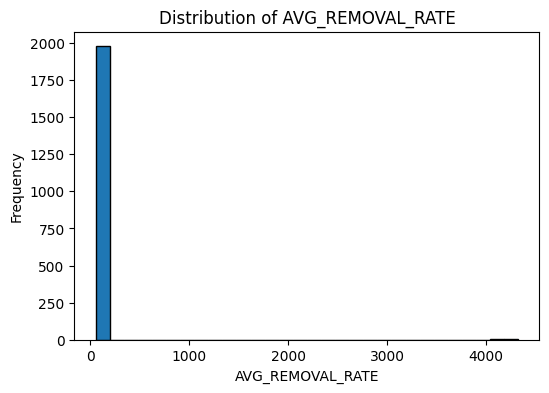

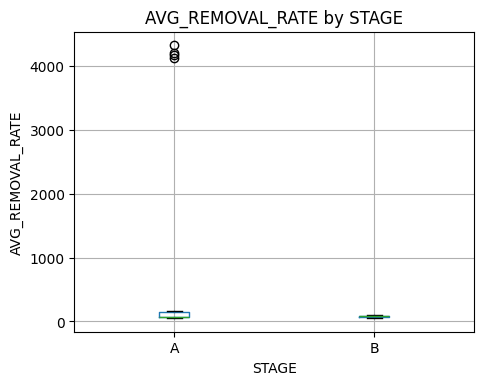

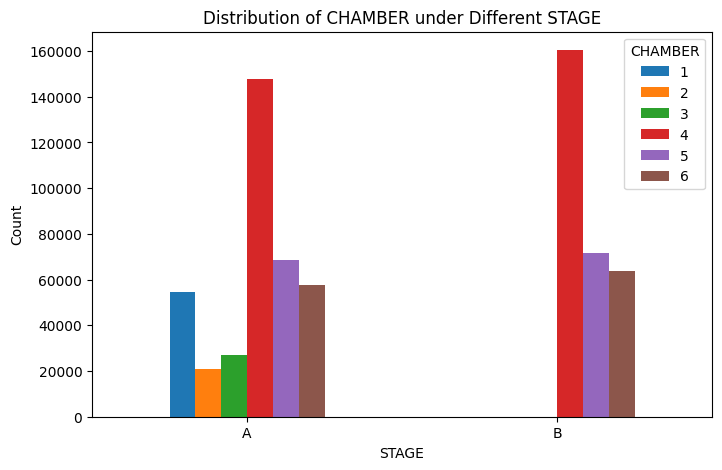

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# 資料路徑
base_dir = Path(r"C:\Users\allen\OneDrive\Desktop\研究所\製造\data\2016 PHM Data Challenge\2016 PHM DATA CHALLENGE CMP DATA SET")
target_path = base_dir / "CMP-training-removalrate.csv"
train_data_dir = base_dir / "CMP-data" / "training"

# 讀取 removal rate 標籤表
df_target = pd.read_csv(target_path)

# 讀取所有 training sensor files 的 STAGE / CHAMBER
train_files = sorted(train_data_dir.glob("CMP-training-*.csv"))

sensor_stage_chamber = []
skipped_files = []

for f in train_files:
    try:
        temp = pd.read_csv(f)

        if temp.empty:
            skipped_files.append({"file_name": f.name, "reason": "empty file"})
            continue

        required_cols = {"STAGE", "CHAMBER"}
        if not required_cols.issubset(temp.columns):
            skipped_files.append({"file_name": f.name, "reason": "missing required columns"})
            continue

        temp = temp[["STAGE", "CHAMBER"]].copy()
        temp["CHAMBER"] = temp["CHAMBER"].astype(str).str.replace(".0", "", regex=False)

        sensor_stage_chamber.append(temp)

    except Exception as e:
        skipped_files.append({"file_name": f.name, "reason": str(e)})

df_sensor_all = pd.concat(sensor_stage_chamber, ignore_index=True)
df_skipped = pd.DataFrame(skipped_files)

print("=== Target Table Summary ===")
print("資料集形狀:", df_target.shape)
print("樣本數:", df_target.shape[0])
print("欄位數:", df_target.shape[1])

print("\n欄位名稱:")
print(df_target.columns.tolist())

print("\n缺失值數量:")
print(df_target.isnull().sum())

print("\nSTAGE 分布:")
display(df_target["STAGE"].value_counts(dropna=False))

print("\nAVG_REMOVAL_RATE 描述統計:")
display(df_target["AVG_REMOVAL_RATE"].describe())

print("\n唯一 WAFER_ID 數量:", df_target["WAFER_ID"].nunique())

print("\n=== Sensor Data Summary ===")
print("Training sensor files:", len(train_files))
print("Successfully loaded files:", len(train_files) - len(df_skipped))
print("Skipped files:", len(df_skipped))

print("\nCHAMBER 分布:")
display(df_sensor_all["CHAMBER"].value_counts(dropna=False).sort_index())

print("\nSTAGE × CHAMBER 分布:")
display(pd.crosstab(df_sensor_all["STAGE"], df_sensor_all["CHAMBER"]))

if not df_skipped.empty:
    print("\nSkipped file summary:")
    display(df_skipped)

# 視覺化 1：AVG_REMOVAL_RATE 分布
plt.figure(figsize=(6, 4))
plt.hist(df_target["AVG_REMOVAL_RATE"], bins=30, edgecolor="black")
plt.title("Distribution of AVG_REMOVAL_RATE")
plt.xlabel("AVG_REMOVAL_RATE")
plt.ylabel("Frequency")
plt.show()

# 視覺化 2：AVG_REMOVAL_RATE 在不同 STAGE 的分布
df_target.boxplot(column="AVG_REMOVAL_RATE", by="STAGE", figsize=(5, 4))
plt.title("AVG_REMOVAL_RATE by STAGE")
plt.suptitle("")
plt.xlabel("STAGE")
plt.ylabel("AVG_REMOVAL_RATE")
plt.show()

# 視覺化 3：不同 STAGE 下的 CHAMBER 分布
stage_chamber_ct = pd.crosstab(df_sensor_all["STAGE"], df_sensor_all["CHAMBER"])
stage_chamber_ct.plot(kind="bar", figsize=(8, 5))
plt.title("Distribution of CHAMBER under Different STAGE")
plt.xlabel("STAGE")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="CHAMBER")
plt.show()



=== Test Target Summary ===
df_test_target shape: (424, 3)
樣本數: 424
欄位數: 3

欄位名稱:
['WAFER_ID', 'STAGE', 'AVG_REMOVAL_RATE']

缺失值數量:
WAFER_ID            0
STAGE               0
AVG_REMOVAL_RATE    0
dtype: int64

STAGE 分布:


STAGE
A    238
B    186
Name: count, dtype: int64


AVG_REMOVAL_RATE 描述統計:


count    424.000000
mean      89.935728
std       29.595945
min       54.502500
25%       72.672600
50%       78.575625
75%       89.199038
max      163.797150
Name: AVG_REMOVAL_RATE, dtype: float64


唯一 WAFER_ID 數量: 415

=== Test Sensor Summary ===
df_test_sensor shape: (156262, 26)
讀取成功檔案數: 155
Skipped test files: 30


,file_name,reason
0,CMP-test-008.csv,empty file
1,CMP-test-014.csv,empty file
2,CMP-test-019.csv,empty file
3,CMP-test-020.csv,empty file
4,CMP-test-030.csv,empty file



CHAMBER 分布:


CHAMBER
1    10582
2     4139
3     5276
4    65846
5    30792
6    39627
Name: count, dtype: int64


STAGE × CHAMBER 分布:


CHAMBER,1,2,3,4,5,6
STAGE,,,,,,
A,10582,4139,5276,30600,14971,26230
B,0,0,0,35246,15821,13397


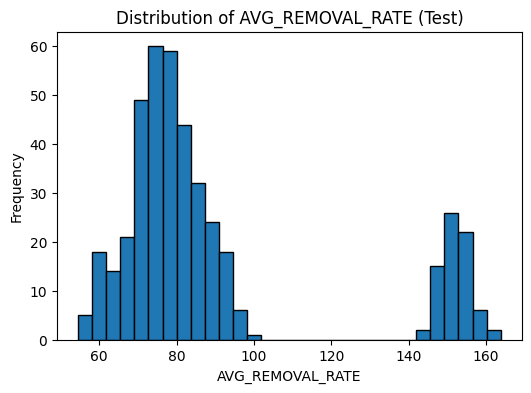

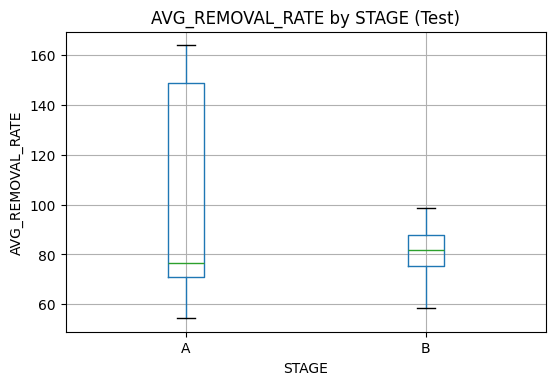

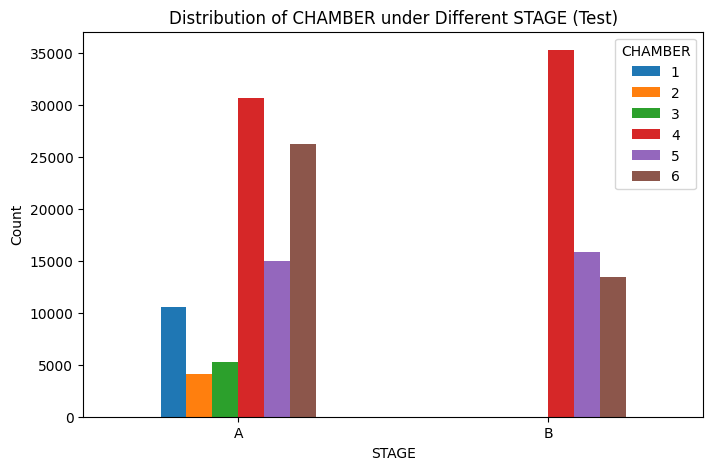

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# 路徑設定
base_dir = Path(r"C:\Users\allen\OneDrive\Desktop\研究所\製造\data\2016 PHM Data Challenge\2016 PHM DATA CHALLENGE CMP DATA SET")
test_target_path = base_dir / "CMP-test-removalrate.csv"
test_data_dir = base_dir / "CMP-data" / "test"

# 讀取 test target
df_test_target = pd.read_csv(test_target_path)

# 讀取 test sensor files
test_files = sorted(test_data_dir.glob("CMP-test-*.csv"))

test_sensor_frames = []
test_skipped_files = []

for f in test_files:
    try:
        temp = pd.read_csv(f)

        if temp.empty:
            test_skipped_files.append({"file_name": f.name, "reason": "empty file"})
            continue

        if "CHAMBER" in temp.columns:
            temp["CHAMBER"] = temp["CHAMBER"].astype(str).str.replace(".0", "", regex=False)

        temp["source_file"] = f.name
        test_sensor_frames.append(temp)

    except Exception as e:
        test_skipped_files.append({"file_name": f.name, "reason": str(e)})

df_test_sensor = pd.concat(test_sensor_frames, ignore_index=True)
df_test_skipped = pd.DataFrame(test_skipped_files)

print("=== Test Target Summary ===")
print("df_test_target shape:", df_test_target.shape)
print("樣本數:", df_test_target.shape[0])
print("欄位數:", df_test_target.shape[1])

print("\n欄位名稱:")
print(df_test_target.columns.tolist())

print("\n缺失值數量:")
print(df_test_target.isnull().sum())

print("\nSTAGE 分布:")
display(df_test_target["STAGE"].value_counts(dropna=False))

print("\nAVG_REMOVAL_RATE 描述統計:")
display(df_test_target["AVG_REMOVAL_RATE"].describe())

print("\n唯一 WAFER_ID 數量:", df_test_target["WAFER_ID"].nunique())

print("\n=== Test Sensor Summary ===")
print("df_test_sensor shape:", df_test_sensor.shape)
print("讀取成功檔案數:", len(test_sensor_frames))
print("Skipped test files:", len(df_test_skipped))

if not df_test_skipped.empty:
    display(df_test_skipped.head())

print("\nCHAMBER 分布:")
display(df_test_sensor["CHAMBER"].value_counts(dropna=False).sort_index())

print("\nSTAGE × CHAMBER 分布:")
display(pd.crosstab(df_test_sensor["STAGE"], df_test_sensor["CHAMBER"]))

# 視覺化：AVG_REMOVAL_RATE 分布
plt.figure(figsize=(6, 4))
plt.hist(df_test_target["AVG_REMOVAL_RATE"], bins=30, edgecolor="black")
plt.title("Distribution of AVG_REMOVAL_RATE (Test)")
plt.xlabel("AVG_REMOVAL_RATE")
plt.ylabel("Frequency")
plt.show()

# 視覺化：依 STAGE 的分布
df_test_target.boxplot(column="AVG_REMOVAL_RATE", by="STAGE", figsize=(6, 4))
plt.title("AVG_REMOVAL_RATE by STAGE (Test)")
plt.suptitle("")
plt.xlabel("STAGE")
plt.ylabel("AVG_REMOVAL_RATE")
plt.show()

# 視覺化：STAGE × CHAMBER
stage_chamber_ct_test = pd.crosstab(df_test_sensor["STAGE"], df_test_sensor["CHAMBER"])
stage_chamber_ct_test.plot(kind="bar", figsize=(8, 5))
plt.title("Distribution of CHAMBER under Different STAGE (Test)")
plt.xlabel("STAGE")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="CHAMBER")
plt.show()


## 2.1 製造數據分析架構與資料摘要

先對 CMP 製程資料中的 training 與 testing datasets 進行基本摘要分析，作為後續資料清理、特徵建構、建模與製程解讀的基礎。資料主要分為兩部分：一是 removal rate 標籤表，用來提供預測目標 `AVG_REMOVAL_RATE`；二是 wafer 對應的 sensor time-series files，用來補充製程設備與感測資訊。

training data 的基本摘要分析：
- removal rate 標籤表中，共有 1981 筆資料與 3 個欄位，分別為 `WAFER_ID`、`STAGE` 與 `AVG_REMOVAL_RATE`，且三個欄位皆無缺失值。其中共有 1699 個唯一 `WAFER_ID`，表示部分 wafer 可能在不同製程階段下重複出現。就 `STAGE` 分布而言，`STAGE A` 有 1166 筆，`STAGE B` 有 815 筆，顯示兩個製程階段的樣本量並不完全平均。

- 目標變數 `AVG_REMOVAL_RATE` 的平均值約為 98.63，最小值約為 53.43，最大值高達 4326.15，顯示其分布範圍非常大，可能存在極端值或異常觀測，因此後續需進一步檢查資料品質與目標變數分布特性。

- training sensor files 共 185 個，其中 184 個可成功讀取，1 個檔案為空檔。將所有有效 sensor rows 整合後，共有 672,744 筆感測資料。`CHAMBER` 分布顯示資料主要集中在 `CHAMBER 4`、`5` 與 `6`，其中以 `CHAMBER 4` 最多；而 `CHAMBER 1`、`2`、`3` 的資料量相對較少。若進一步觀察 `STAGE` 與 `CHAMBER` 的交叉分布，可發現 `STAGE A` 涵蓋 `CHAMBER 1` 到 `6`，但 `STAGE B` 僅出現在 `CHAMBER 4`、`5` 與 `6`。此結果表示不同製程階段與設備腔體之間存在明顯的結構性差異，後續在建模與製程分析時應將 `STAGE` 與 `CHAMBER` 納入重要考量。

testing data 的基本摘要分析：
- removal rate 標籤表共有 424 筆資料與 3 個欄位，分別為 `WAFER_ID`、`STAGE` 與 `AVG_REMOVAL_RATE`，且三個欄位皆無缺失值。其中共有 415 個唯一 `WAFER_ID`，表示部分 wafer 亦可能在不同製程階段下重複出現。就 `STAGE` 分布而言，`STAGE A` 有 238 筆，`STAGE B` 有 186 筆，兩者樣本數略有差異，但整體分布與 training data 類似。

- 目標變數 `AVG_REMOVAL_RATE` 在 testing data 中的平均值約為 89.94，最小值約為 54.50，最大值約為 163.80，整體數值範圍明顯較 training data 集中，未出現極端高值。從分布圖可觀察到，testing data 的 `AVG_REMOVAL_RATE` 呈現雙峰現象，顯示資料中可能仍存在兩種主要製程狀態或設備操作模式，且此現象與 training data 的分布特性一致。

- testing sensor files 方面，共有 185 個檔案，其中 155 個可成功讀取，30 個為空檔，因此後續分析僅納入有效感測資料。將所有有效 sensor rows 整合後，共有 156,262 筆感測資料。`CHAMBER` 分布顯示資料主要集中在 `CHAMBER 4`、`5` 與 `6`，其中仍以 `CHAMBER 4` 最多；而 `CHAMBER 1`、`2`、`3` 的資料量相對較少。若進一步觀察 `STAGE` 與 `CHAMBER` 的交叉分布，可發現 `STAGE A` 涵蓋 `CHAMBER 1` 到 `6`，但 `STAGE B` 僅出現在 `CHAMBER 4`、`5` 與 `6`。此結果與 training data 一致，表示 testing data 在製程階段與設備腔體配置上保有相似的結構特性，因此可作為後續模型泛化能力驗證的合理基礎。


In [4]:
from pathlib import Path
import pandas as pd

# 資料路徑
base_dir = Path(r"C:\Users\allen\OneDrive\Desktop\研究所\製造\data\2016 PHM Data Challenge\2016 PHM DATA CHALLENGE CMP DATA SET")
target_path = base_dir / "CMP-training-removalrate.csv"
train_data_dir = base_dir / "CMP-data" / "training"

# 讀取 target table
df_target = pd.read_csv(target_path)

# 合併所有 training sensor files
train_files = sorted(train_data_dir.glob("CMP-training-*.csv"))

sensor_frames = []
skipped_files = []

for f in train_files:
    try:
        temp = pd.read_csv(f)

        if temp.empty:
            skipped_files.append({"file_name": f.name, "reason": "empty file"})
            continue

        if "CHAMBER" in temp.columns:
            temp["CHAMBER"] = temp["CHAMBER"].astype(str).str.replace(".0", "", regex=False)

        temp["source_file"] = f.name
        sensor_frames.append(temp)

    except Exception as e:
        skipped_files.append({"file_name": f.name, "reason": str(e)})

df_sensor = pd.concat(sensor_frames, ignore_index=True)
df_skipped = pd.DataFrame(skipped_files)

print("df_target shape:", df_target.shape)
print("df_sensor shape:", df_sensor.shape)
print("skipped files:", len(df_skipped))


df_target shape: (1981, 3)
df_sensor shape: (672744, 26)
skipped files: 1


In [5]:
# 重複樣本檢查
print("=== Duplicate Check ===")

# target table 完全重複列
target_dup_count = df_target.duplicated().sum()
print("Target duplicated rows:", target_dup_count)

# sensor data 完全重複列
sensor_dup_count = df_sensor.duplicated().sum()
print("Sensor duplicated rows:", sensor_dup_count)

# 以關鍵欄位檢查重複觀測
key_cols = ["WAFER_ID", "STAGE", "TIMESTAMP"]
available_key_cols = [col for col in key_cols if col in df_sensor.columns]

if len(available_key_cols) == len(key_cols):
    key_dup_count = df_sensor.duplicated(subset=available_key_cols).sum()
    print("Sensor duplicated rows by WAFER_ID + STAGE + TIMESTAMP:", key_dup_count)
else:
    print("Key columns not complete, skipped key-based duplicate check.")


=== Duplicate Check ===
Target duplicated rows: 0
Sensor duplicated rows: 1819
Sensor duplicated rows by WAFER_ID + STAGE + TIMESTAMP: 2221


In [6]:
# 遺失值檢查
print("=== Missing Value Check ===")

target_missing = pd.DataFrame({
    "Missing Count": df_target.isnull().sum(),
    "Missing Ratio": df_target.isnull().mean()
}).sort_values("Missing Ratio", ascending=False)

sensor_missing = pd.DataFrame({
    "Missing Count": df_sensor.isnull().sum(),
    "Missing Ratio": df_sensor.isnull().mean()
}).sort_values("Missing Ratio", ascending=False)

print("Target missing summary:")
display(target_missing)

print("Sensor missing summary (top 20):")
display(sensor_missing.head(20))


=== Missing Value Check ===
Target missing summary:


,Missing Count,Missing Ratio
WAFER_ID,0,0.0
STAGE,0,0.0
AVG_REMOVAL_RATE,0,0.0


Sensor missing summary (top 20):


,Missing Count,Missing Ratio
MACHINE_ID,0,0.0
MACHINE_DATA,0,0.0
TIMESTAMP,0,0.0
WAFER_ID,0,0.0
STAGE,0,0.0
CHAMBER,0,0.0
USAGE_OF_BACKING_FILM,0,0.0
USAGE_OF_DRESSER,0,0.0
USAGE_OF_POLISHING_TABLE,0,0.0
USAGE_OF_DRESSER_TABLE,0,0.0


In [7]:
# 類別欄位格式一致性檢查
print("=== Category Consistency Check ===")

if "CHAMBER" in df_sensor.columns:
    print("Unique CHAMBER values:")
    print(sorted(df_sensor["CHAMBER"].dropna().astype(str).unique()))

if "STAGE" in df_sensor.columns:
    print("\nUnique STAGE values:")
    print(sorted(df_sensor["STAGE"].dropna().astype(str).unique()))


=== Category Consistency Check ===
Unique CHAMBER values:
['1', '2', '3', '4', '5', '6']

Unique STAGE values:
['A', 'B']


In [8]:
# 低變異欄位檢查
print("=== Low Variance Feature Check ===")

numeric_cols = df_sensor.select_dtypes(include="number").columns.tolist()

# 不把識別欄位拿去做低變異判斷
exclude_cols = ["TIMESTAMP"]
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

sensor_numeric = df_sensor[numeric_cols].copy()

variance = sensor_numeric.var()
low_variance_threshold = 1e-5
low_variance_cols = variance[variance < low_variance_threshold].index.tolist()

print("Numeric feature count:", len(numeric_cols))
print("Low variance feature count:", len(low_variance_cols))
print("Low variance features:")
print(low_variance_cols)


=== Low Variance Feature Check ===
Numeric feature count: 22
Low variance feature count: 1
Low variance features:
['MACHINE_ID']


=== AVG_REMOVAL_RATE Outlier Check ===
Q1: 72.3765
Q3: 88.70205
IQR: 16.325550000000007
Lower bound: 47.88817499999998
Upper bound: 113.19037500000002
Outlier count: 368
Outlier ratio: 0.18576476527006563

Outlier count by STAGE:


is_outlier,False,True
STAGE,,
A,798,368
B,815,0



Top 20 largest AVG_REMOVAL_RATE:


,WAFER_ID,STAGE,AVG_REMOVAL_RATE,is_outlier
1675,2058207580,A,4326.15405,True
892,1834206730,A,4202.11245,True
894,1834206944,A,4182.41655,True
897,1834206972,A,4129.49400,True
1263,1852206942,A,162.64170,True
1260,1842206722,A,162.56205,True
1141,1834206746,A,161.06895,True
1264,1852207012,A,160.98240,True
1466,2062207658,A,160.86330,True
1315,1842206770,A,160.25760,True


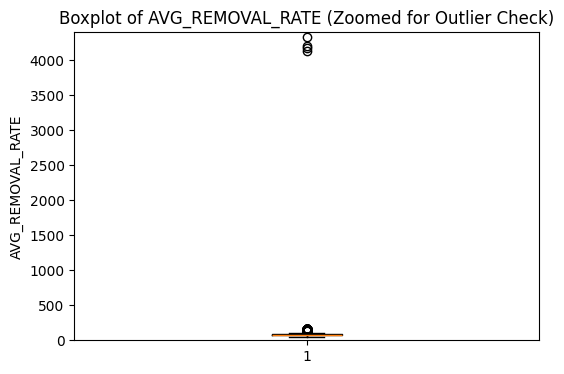

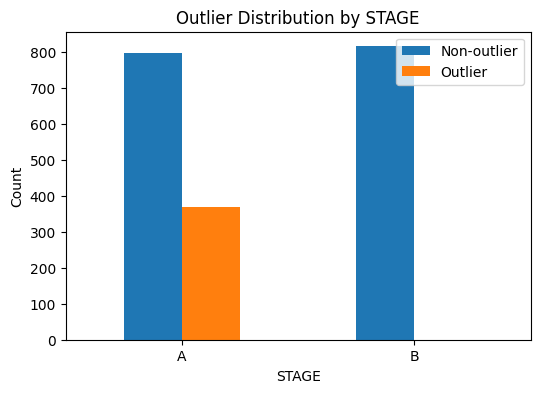

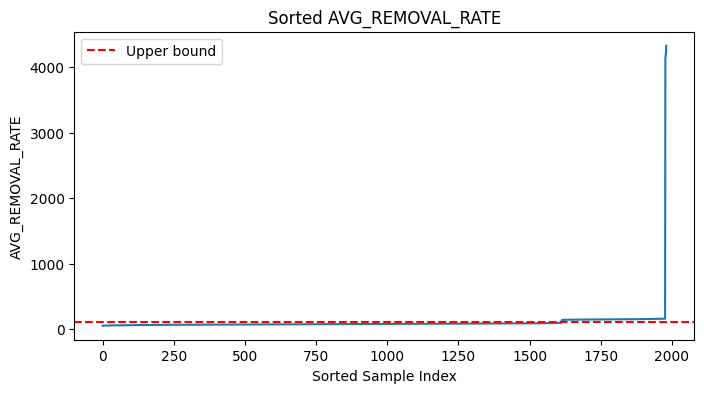

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

print("=== AVG_REMOVAL_RATE Outlier Check ===")

# IQR outlier 定義
Q1 = df_target["AVG_REMOVAL_RATE"].quantile(0.25)
Q3 = df_target["AVG_REMOVAL_RATE"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_target_outlier_view = df_target.copy()
df_target_outlier_view["is_outlier"] = (
    (df_target_outlier_view["AVG_REMOVAL_RATE"] < lower_bound) |
    (df_target_outlier_view["AVG_REMOVAL_RATE"] > upper_bound)
)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Outlier count:", df_target_outlier_view["is_outlier"].sum())
print("Outlier ratio:", df_target_outlier_view["is_outlier"].mean())

print("\nOutlier count by STAGE:")
display(pd.crosstab(df_target_outlier_view["STAGE"], df_target_outlier_view["is_outlier"]))

print("\nTop 20 largest AVG_REMOVAL_RATE:")
display(
    df_target_outlier_view
    .sort_values("AVG_REMOVAL_RATE", ascending=False)
    .head(20)
)

# 1. 放大版 boxplot：專門看主體分布與極端值
plt.figure(figsize=(6, 4))
plt.boxplot(df_target_outlier_view["AVG_REMOVAL_RATE"], vert=True)
plt.ylim(0, 4400)
plt.title("Boxplot of AVG_REMOVAL_RATE (Zoomed for Outlier Check)")
plt.ylabel("AVG_REMOVAL_RATE")
plt.show()

# 2. outlier vs non-outlier counts by STAGE
stage_outlier_ct = pd.crosstab(
    df_target_outlier_view["STAGE"],
    df_target_outlier_view["is_outlier"]
)
stage_outlier_ct.plot(kind="bar", figsize=(6, 4))
plt.title("Outlier Distribution by STAGE")
plt.xlabel("STAGE")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(["Non-outlier", "Outlier"])
plt.show()

# 3. 按數值排序看尾端斷層
plt.figure(figsize=(8, 4))
sorted_vals = df_target_outlier_view["AVG_REMOVAL_RATE"].sort_values().reset_index(drop=True)
plt.plot(sorted_vals)
plt.axhline(upper_bound, color="red", linestyle="--", label="Upper bound")
plt.title("Sorted AVG_REMOVAL_RATE")
plt.xlabel("Sorted Sample Index")
plt.ylabel("AVG_REMOVAL_RATE")
plt.legend()
plt.show()


df_target_clean shape: (1981, 3)
df_sensor_clean shape: (670925, 25)
Extreme outlier count: 4
df_target_no_outlier shape: (1977, 3)

Removed extreme outliers:


,WAFER_ID,STAGE,AVG_REMOVAL_RATE
1675,2058207580,A,4326.15405
892,1834206730,A,4202.11245
894,1834206944,A,4182.41655
897,1834206972,A,4129.49400


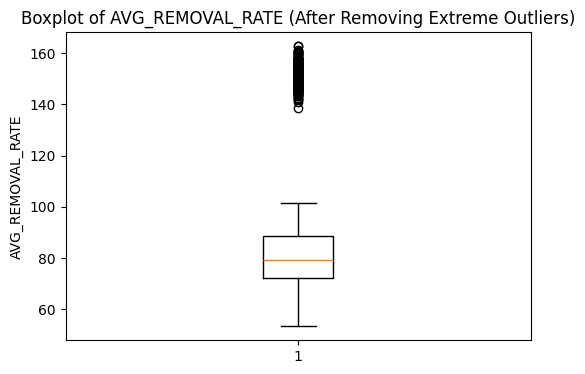

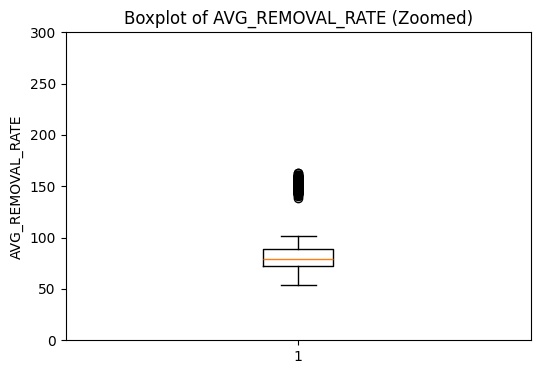

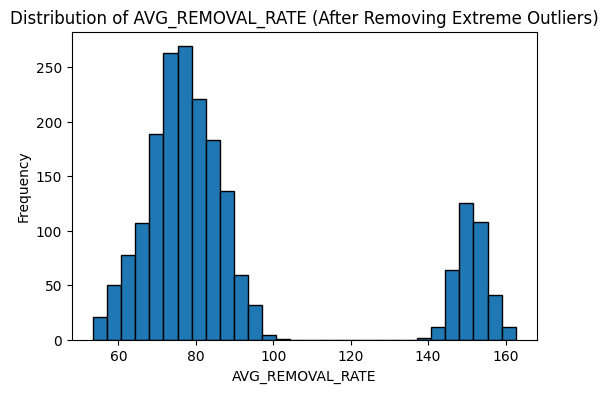

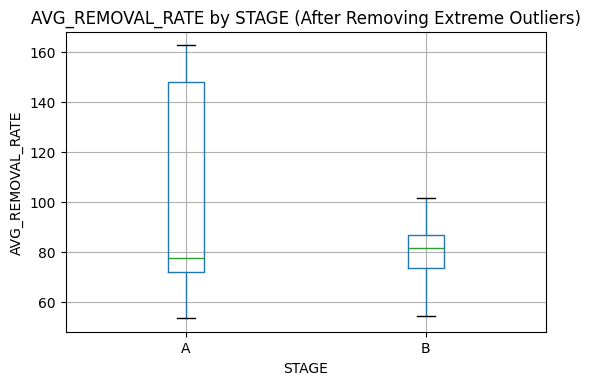

In [10]:
import matplotlib.pyplot as plt

# target table
df_target_clean = df_target.drop_duplicates().copy()

# sensor data
df_sensor_clean = df_sensor.drop_duplicates().copy()

# 移除低變異欄位
low_variance_cols_to_drop = ["MACHINE_ID"]
df_sensor_clean = df_sensor_clean.drop(columns=low_variance_cols_to_drop, errors="ignore")

# 只移除超級極端高值
extreme_threshold = 300

extreme_outliers = df_target_clean[
    df_target_clean["AVG_REMOVAL_RATE"] > extreme_threshold
].copy()

df_target_no_outlier = df_target_clean[
    df_target_clean["AVG_REMOVAL_RATE"] <= extreme_threshold
].copy()

print("df_target_clean shape:", df_target_clean.shape)
print("df_sensor_clean shape:", df_sensor_clean.shape)
print("Extreme outlier count:", len(extreme_outliers))
print("df_target_no_outlier shape:", df_target_no_outlier.shape)

print("\nRemoved extreme outliers:")
display(extreme_outliers.sort_values("AVG_REMOVAL_RATE", ascending=False))

# 刪除極端值後的 boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(df_target_no_outlier["AVG_REMOVAL_RATE"], vert=True)
plt.title("Boxplot of AVG_REMOVAL_RATE (After Removing Extreme Outliers)")
plt.ylabel("AVG_REMOVAL_RATE")
plt.show()

# 放大主體區間
plt.figure(figsize=(6, 4))
plt.boxplot(df_target_no_outlier["AVG_REMOVAL_RATE"], vert=True)
plt.ylim(0, 300)
plt.title("Boxplot of AVG_REMOVAL_RATE (Zoomed)")
plt.ylabel("AVG_REMOVAL_RATE")
plt.show()

# histogram
plt.figure(figsize=(6, 4))
plt.hist(df_target_no_outlier["AVG_REMOVAL_RATE"], bins=30, edgecolor="black")
plt.title("Distribution of AVG_REMOVAL_RATE (After Removing Extreme Outliers)")
plt.xlabel("AVG_REMOVAL_RATE")
plt.ylabel("Frequency")
plt.show()

# 依 STAGE 看分布
df_target_no_outlier.boxplot(column="AVG_REMOVAL_RATE", by="STAGE", figsize=(6, 4))
plt.title("AVG_REMOVAL_RATE by STAGE (After Removing Extreme Outliers)")
plt.suptitle("")
plt.xlabel("STAGE")
plt.ylabel("AVG_REMOVAL_RATE")
plt.show()


In [11]:
# testing target table
df_test_target_clean = df_test_target.drop_duplicates().copy()

# testing sensor data
df_test_sensor_clean = df_test_sensor.drop_duplicates().copy()

# 使用與 training 相同的低變異欄位移除規則
low_variance_cols_to_drop = ["MACHINE_ID"]
df_test_sensor_clean = df_test_sensor_clean.drop(columns=low_variance_cols_to_drop, errors="ignore")

print("df_test_target_clean shape:", df_test_target_clean.shape)
print("df_test_sensor_clean shape:", df_test_sensor_clean.shape)
print("Dropped low variance columns:", low_variance_cols_to_drop)
print("Removed test target duplicate rows:", len(df_test_target) - len(df_test_target_clean))
print("Removed test sensor duplicate rows:", len(df_test_sensor) - len(df_test_sensor_clean))


df_test_target_clean shape: (424, 3)
df_test_sensor_clean shape: (156164, 25)
Dropped low variance columns: ['MACHINE_ID']
Removed test target duplicate rows: 0
Removed test sensor duplicate rows: 98


## 2.2 資料品質檢查與前處理

針對 CMP 製程資料進行資料品質檢查與前處理，重點包括重複樣本、類別格式一致性、缺失值、低變異欄位與異常值等問題。為確保後續建模流程一致，因此對 training 與 testing data 採用相同的前處理原則。

training data 資料前處理：
- 在 training target table 中未發現完全重複樣本，因此 `df_target_clean` 維持原始 1981 筆資料。而 sensor data 中存在重複觀測，因此先移除重複列，以降低資料冗餘與重複量測對後續分析的干擾。

- 類別欄位方面，`CHAMBER` 原始資料存在 `1` / `1.0`、`4` / `4.0` 等格式不一致問題，因此先將其統一為一致的類別表示方式，以避免同一設備腔體被錯誤視為不同類別。

- 缺失值檢查方面，training 的 target table 中，`WAFER_ID`、`STAGE` 與 `AVG_REMOVAL_RATE` 均無缺失值。另外有在 sensor files 中發現部分空檔，因此於前處理階段直接排除，僅保留可成功讀取之感測資料作為後續分析基礎。

- 針對冗餘欄位，低變異檢查結果顯示 `MACHINE_ID` 幾乎不具有變化，因此將其視為低資訊量特徵並予以移除。

- 在異常值處理方面，原始 training target 中的 `AVG_REMOVAL_RATE` 存在少數極端高值，且明顯偏離主要分布。考量這些樣本可能影響模型穩定性，因此僅移除少數超級極端值，建立 `df_target_no_outlier` 作為後續訓練資料版本。

testing data 資料前處理：
- 在 testing data 中，`df_test_target_clean` 亦未發現完全重複樣本，而 `df_test_sensor_clean` 則移除了 98 筆重複列，表示 testing sensor data 同樣存在少量重複觀測。

- 類別欄位方面與 training data 處理方式相同，以確保兩者類別結構一致。

- 缺失值檢查方面與 training data 處理方式相同。

- 冗餘欄位與 training data 處理方式相同。

- 異常值處理方面 testing target，保留其原始分布，不額外進行異常值刪除，以作為模型泛化能力驗證之依據。

Selected WAFER_ID: 3021014294
Selected STAGE: B
Number of time points: 5485
Number of numeric variables: 20
['MACHINE_DATA', 'USAGE_OF_BACKING_FILM', 'USAGE_OF_DRESSER', 'USAGE_OF_POLISHING_TABLE', 'USAGE_OF_DRESSER_TABLE', 'PRESSURIZED_CHAMBER_PRESSURE', 'MAIN_OUTER_AIR_BAG_PRESSURE', 'CENTER_AIR_BAG_PRESSURE', 'RETAINER_RING_PRESSURE', 'RIPPLE_AIR_BAG_PRESSURE', 'USAGE_OF_MEMBRANE', 'USAGE_OF_PRESSURIZED_SHEET', 'SLURRY_FLOW_LINE_A', 'SLURRY_FLOW_LINE_B', 'SLURRY_FLOW_LINE_C', 'WAFER_ROTATION', 'STAGE_ROTATION', 'HEAD_ROTATION', 'DRESSING_WATER_STATUS', 'EDGE_AIR_BAG_PRESSURE']


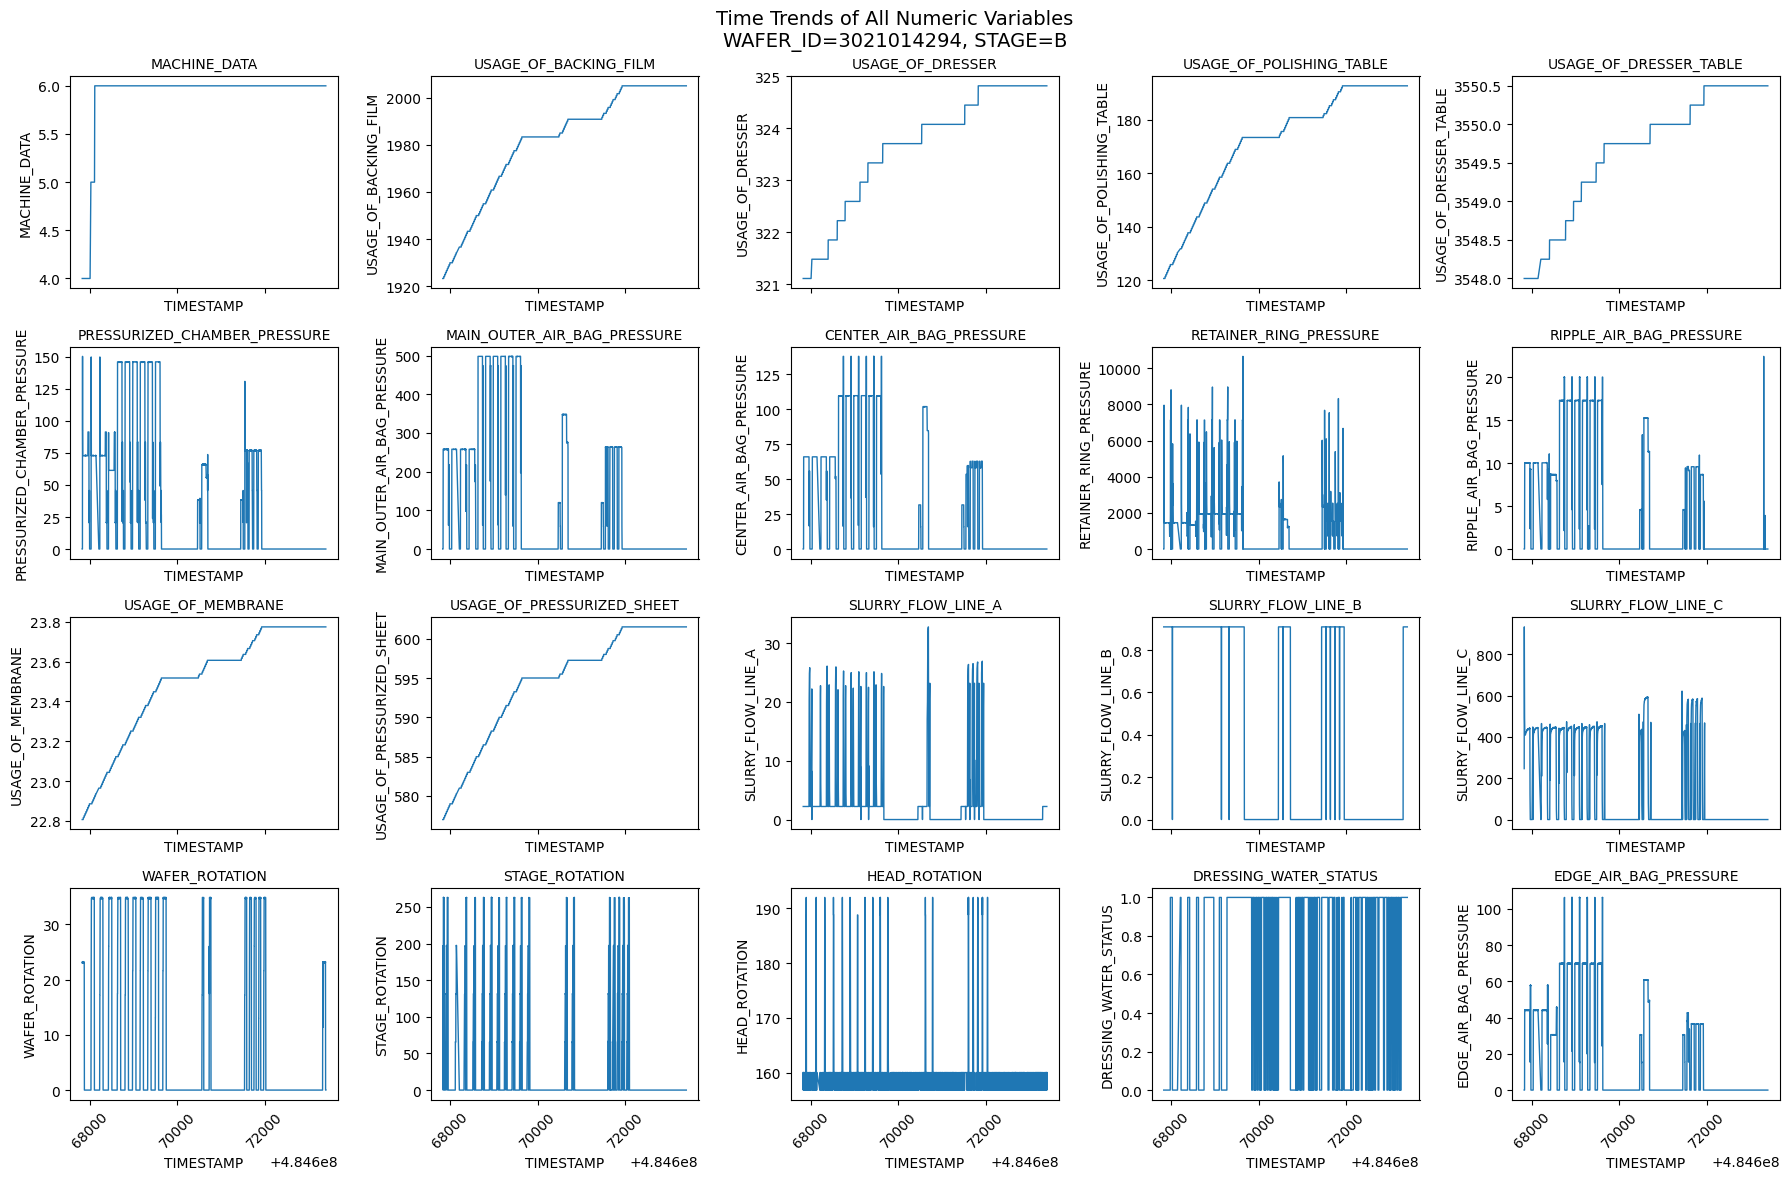

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import math

# 選一組製程資料來看：這裡用時間點最多的一組 WAFER_ID + STAGE
run_lengths = (
    df_sensor_clean.groupby(["WAFER_ID", "STAGE"])
    .size()
    .reset_index(name="n_points")
    .sort_values("n_points", ascending=False)
)

sample_wafer = run_lengths.iloc[0]["WAFER_ID"]
sample_stage = run_lengths.iloc[0]["STAGE"]

df_one_run = df_sensor_clean[
    (df_sensor_clean["WAFER_ID"] == sample_wafer) &
    (df_sensor_clean["STAGE"] == sample_stage)
].copy()

df_one_run = df_one_run.sort_values("TIMESTAMP")

print("Selected WAFER_ID:", sample_wafer)
print("Selected STAGE:", sample_stage)
print("Number of time points:", len(df_one_run))

# 數值欄位中排除識別欄位
exclude_cols = ["WAFER_ID", "TIMESTAMP"]
plot_cols = df_one_run.select_dtypes(include="number").columns.tolist()
plot_cols = [col for col in plot_cols if col not in exclude_cols]

print("Number of numeric variables:", len(plot_cols))
print(plot_cols)

# 一張 figure 顯示全部變數
n_cols = 5
n_rows = math.ceil(len(plot_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=True)
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].plot(df_one_run["TIMESTAMP"], df_one_run[col], linewidth=1)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("TIMESTAMP")
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis="x", labelrotation=45)

# 刪掉多餘空白子圖
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f"Time Trends of All Numeric Variables\nWAFER_ID={sample_wafer}, STAGE={sample_stage}", fontsize=14)
plt.tight_layout()
plt.show()



=== usage_group ===


,USAGE_OF_BACKING_FILM,USAGE_OF_DRESSER,USAGE_OF_POLISHING_TABLE,USAGE_OF_DRESSER_TABLE,USAGE_OF_MEMBRANE,USAGE_OF_PRESSURIZED_SHEET
USAGE_OF_BACKING_FILM,1.000000,0.015828,0.005999,0.063282,1.000000,1.000000
USAGE_OF_DRESSER,0.015828,1.000000,-0.041714,-0.000297,0.015828,0.015828
USAGE_OF_POLISHING_TABLE,0.005999,-0.041714,1.000000,-0.006808,0.005999,0.005999
USAGE_OF_DRESSER_TABLE,0.063282,-0.000297,-0.006808,1.000000,0.063282,0.063282
USAGE_OF_MEMBRANE,1.000000,0.015828,0.005999,0.063282,1.000000,1.000000
USAGE_OF_PRESSURIZED_SHEET,1.000000,0.015828,0.005999,0.063282,1.000000,1.000000


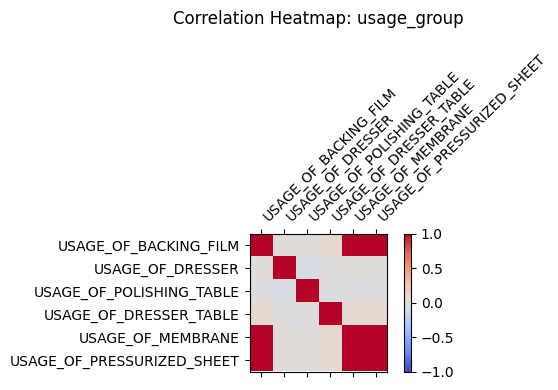


=== air_bag_pressure_group ===


,MAIN_OUTER_AIR_BAG_PRESSURE,CENTER_AIR_BAG_PRESSURE,RIPPLE_AIR_BAG_PRESSURE,EDGE_AIR_BAG_PRESSURE
MAIN_OUTER_AIR_BAG_PRESSURE,1.000000,0.995398,0.992516,0.969258
CENTER_AIR_BAG_PRESSURE,0.995398,1.000000,0.991990,0.971540
RIPPLE_AIR_BAG_PRESSURE,0.992516,0.991990,1.000000,0.975608
EDGE_AIR_BAG_PRESSURE,0.969258,0.971540,0.975608,1.000000


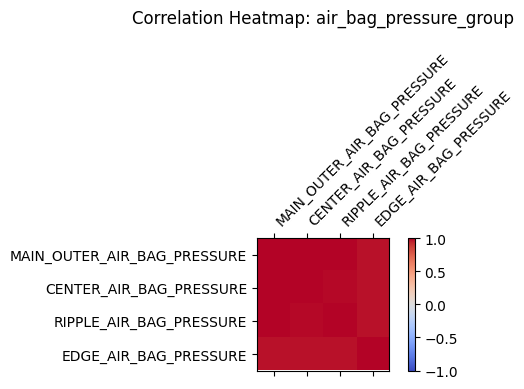


=== rotation_group ===


,WAFER_ROTATION,STAGE_ROTATION,HEAD_ROTATION
WAFER_ROTATION,1.000000,-0.398733,-0.126019
STAGE_ROTATION,-0.398733,1.000000,0.047121
HEAD_ROTATION,-0.126019,0.047121,1.000000


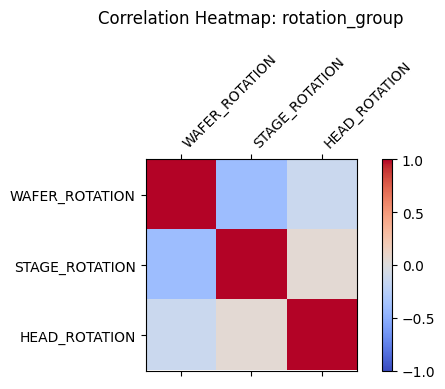


=== slurry_group ===


,SLURRY_FLOW_LINE_A,SLURRY_FLOW_LINE_B,SLURRY_FLOW_LINE_C
SLURRY_FLOW_LINE_A,1.000000,0.304652,-0.188322
SLURRY_FLOW_LINE_B,0.304652,1.000000,0.524631
SLURRY_FLOW_LINE_C,-0.188322,0.524631,1.000000


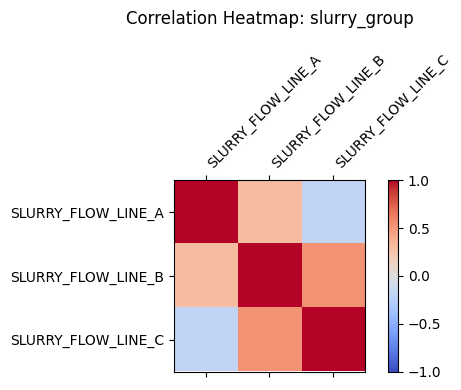

In [14]:
import matplotlib.pyplot as plt
import numpy as np

candidate_groups = {
    "usage_group": [
        "USAGE_OF_BACKING_FILM",
        "USAGE_OF_DRESSER",
        "USAGE_OF_POLISHING_TABLE",
        "USAGE_OF_DRESSER_TABLE",
        "USAGE_OF_MEMBRANE",
        "USAGE_OF_PRESSURIZED_SHEET"
    ],
    "air_bag_pressure_group": [
        "MAIN_OUTER_AIR_BAG_PRESSURE",
        "CENTER_AIR_BAG_PRESSURE",
        "RIPPLE_AIR_BAG_PRESSURE",
        "EDGE_AIR_BAG_PRESSURE"
    ],
    "rotation_group": [
        "WAFER_ROTATION",
        "STAGE_ROTATION",
        "HEAD_ROTATION"
    ],
    "slurry_group": [
        "SLURRY_FLOW_LINE_A",
        "SLURRY_FLOW_LINE_B",
        "SLURRY_FLOW_LINE_C"
    ]
}

for group_name, cols in candidate_groups.items():
    available_cols = [col for col in cols if col in df_sensor_clean.columns]

    if len(available_cols) < 2:
        continue

    print(f"\n=== {group_name} ===")
    corr_mat = df_sensor_clean[available_cols].corr()
    display(corr_mat)

    fig, ax = plt.subplots(figsize=(6, 4))
    cax = ax.matshow(corr_mat, cmap="coolwarm", vmin=-1, vmax=1)
    fig.colorbar(cax)

    ax.set_xticks(range(len(available_cols)))
    ax.set_yticks(range(len(available_cols)))
    ax.set_xticklabels(available_cols, rotation=45, ha="left")
    ax.set_yticklabels(available_cols)

    plt.title(f"Correlation Heatmap: {group_name}", pad=20)
    plt.tight_layout()
    plt.show()


In [15]:
df_sensor_reduced = df_sensor_clean.copy()
df_test_sensor_reduced = df_test_sensor_clean.copy()

# 1. usage 三個完全重複訊號，只留一個
cols_to_drop_usage = [
    "USAGE_OF_MEMBRANE",
    "USAGE_OF_PRESSURIZED_SHEET"
]

# 2. air bag pressure 四個高度相關，只保留一個代表
cols_to_drop_airbag = [
    "CENTER_AIR_BAG_PRESSURE",
    "RIPPLE_AIR_BAG_PRESSURE",
    "EDGE_AIR_BAG_PRESSURE"
]

cols_to_drop = cols_to_drop_usage + cols_to_drop_airbag

df_sensor_reduced = df_sensor_reduced.drop(columns=cols_to_drop, errors="ignore")
df_test_sensor_reduced = df_test_sensor_reduced.drop(columns=cols_to_drop, errors="ignore")

print("Original train sensor shape:", df_sensor_clean.shape)
print("Reduced train sensor shape:", df_sensor_reduced.shape)
print("Original test sensor shape:", df_test_sensor_clean.shape)
print("Reduced test sensor shape:", df_test_sensor_reduced.shape)

print("Dropped columns:")
print(cols_to_drop)


Original train sensor shape: (670925, 25)
Reduced train sensor shape: (670925, 20)
Original test sensor shape: (156164, 25)
Reduced test sensor shape: (156164, 20)
Dropped columns:
['USAGE_OF_MEMBRANE', 'USAGE_OF_PRESSURIZED_SHEET', 'CENTER_AIR_BAG_PRESSURE', 'RIPPLE_AIR_BAG_PRESSURE', 'EDGE_AIR_BAG_PRESSURE']


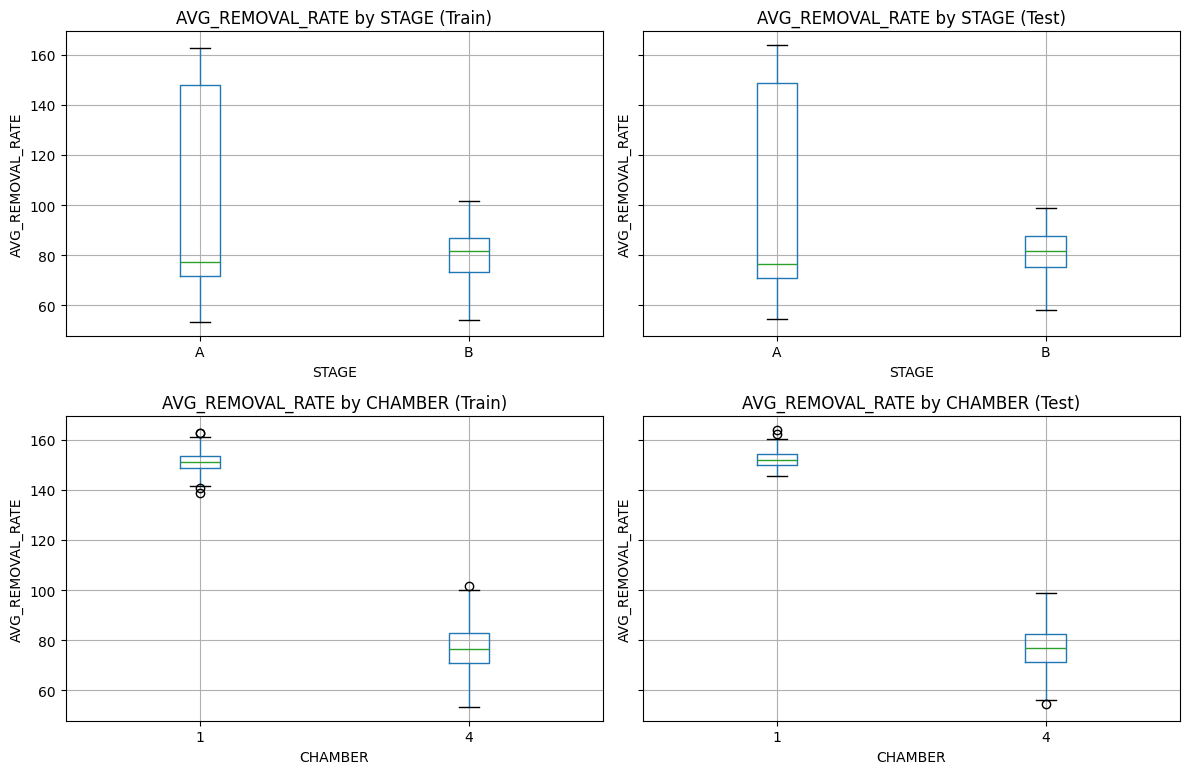

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 先從 sensor data 建立每個 WAFER_ID + STAGE 的 CHAMBER 對應
df_chamber_map = (
    df_sensor_reduced.groupby(["WAFER_ID", "STAGE"])["CHAMBER"]
    .first()
    .reset_index()
)

df_test_chamber_map = (
    df_test_sensor_reduced.groupby(["WAFER_ID", "STAGE"])["CHAMBER"]
    .first()
    .reset_index()
)

# train / test target 合併 CHAMBER
plot_train = pd.merge(
    df_target_no_outlier,
    df_chamber_map,
    on=["WAFER_ID", "STAGE"],
    how="left"
)

plot_test = pd.merge(
    df_test_target_clean,
    df_test_chamber_map,
    on=["WAFER_ID", "STAGE"],
    how="left"
)

# 四格圖
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

# 1. AVG_REMOVAL_RATE by STAGE (Train)
plot_train.boxplot(column="AVG_REMOVAL_RATE", by="STAGE", ax=axes[0, 0])
axes[0, 0].set_title("AVG_REMOVAL_RATE by STAGE (Train)")
axes[0, 0].set_xlabel("STAGE")
axes[0, 0].set_ylabel("AVG_REMOVAL_RATE")

# 2. AVG_REMOVAL_RATE by STAGE (Test)
plot_test.boxplot(column="AVG_REMOVAL_RATE", by="STAGE", ax=axes[0, 1])
axes[0, 1].set_title("AVG_REMOVAL_RATE by STAGE (Test)")
axes[0, 1].set_xlabel("STAGE")
axes[0, 1].set_ylabel("AVG_REMOVAL_RATE")

# 3. AVG_REMOVAL_RATE by CHAMBER (Train)
plot_train.boxplot(column="AVG_REMOVAL_RATE", by="CHAMBER", ax=axes[1, 0])
axes[1, 0].set_title("AVG_REMOVAL_RATE by CHAMBER (Train)")
axes[1, 0].set_xlabel("CHAMBER")
axes[1, 0].set_ylabel("AVG_REMOVAL_RATE")

# 4. AVG_REMOVAL_RATE by CHAMBER (Test)
plot_test.boxplot(column="AVG_REMOVAL_RATE", by="CHAMBER", ax=axes[1, 1])
axes[1, 1].set_title("AVG_REMOVAL_RATE by CHAMBER (Test)")
axes[1, 1].set_xlabel("CHAMBER")
axes[1, 1].set_ylabel("AVG_REMOVAL_RATE")

plt.suptitle("")
plt.tight_layout()
plt.show()


In [17]:
import pandas as pd

# 建立 train EDA table
group_cols = ["WAFER_ID", "STAGE"]
exclude_cols = ["TIMESTAMP", "WAFER_ID"]

numeric_cols_train = df_sensor_reduced.select_dtypes(include="number").columns.tolist()
numeric_cols_train = [col for col in numeric_cols_train if col not in exclude_cols]

df_sensor_agg_train = df_sensor_reduced.groupby(group_cols)[numeric_cols_train].agg(["mean", "std", "max", "min"])
df_sensor_agg_train.columns = [f"{col}_{stat}" for col, stat in df_sensor_agg_train.columns]
df_sensor_agg_train = df_sensor_agg_train.reset_index()

df_eda_train = pd.merge(
    df_target_no_outlier,
    df_sensor_agg_train,
    on=["WAFER_ID", "STAGE"],
    how="inner"
)

# 建立 test EDA table
numeric_cols_test = df_test_sensor_reduced.select_dtypes(include="number").columns.tolist()
numeric_cols_test = [col for col in numeric_cols_test if col not in exclude_cols]

df_sensor_agg_test = df_test_sensor_reduced.groupby(group_cols)[numeric_cols_test].agg(["mean", "std", "max", "min"])
df_sensor_agg_test.columns = [f"{col}_{stat}" for col, stat in df_sensor_agg_test.columns]
df_sensor_agg_test = df_sensor_agg_test.reset_index()

df_eda_test = pd.merge(
    df_test_target_clean,
    df_sensor_agg_test,
    on=["WAFER_ID", "STAGE"],
    how="inner"
)

print("df_eda_train shape:", df_eda_train.shape)
print("df_eda_test shape:", df_eda_test.shape)




df_eda_train shape: (1977, 63)
df_eda_test shape: (424, 63)


In [18]:
corr = df_eda_train.select_dtypes(include="number").corr()["AVG_REMOVAL_RATE"].sort_values(ascending=False)

print("Top positive correlations:")
display(corr.head(10))

print("Top negative correlations:")
display(corr.tail(10))

corr_test = df_eda_test.select_dtypes(include="number").corr()["AVG_REMOVAL_RATE"].sort_values(ascending=False)

print("Top positive correlations (Test):")
display(corr_test.head(10))

print("Top negative correlations (Test):")
display(corr_test.tail(10))


Top positive correlations:


AVG_REMOVAL_RATE               1.000000
MACHINE_DATA_std               0.521369
DRESSING_WATER_STATUS_std      0.187616
SLURRY_FLOW_LINE_B_max         0.139820
SLURRY_FLOW_LINE_B_std         0.129819
USAGE_OF_DRESSER_TABLE_min     0.113192
USAGE_OF_DRESSER_TABLE_mean    0.113160
USAGE_OF_DRESSER_TABLE_max     0.113116
WAFER_ID                       0.105237
USAGE_OF_BACKING_FILM_min      0.074622
Name: AVG_REMOVAL_RATE, dtype: float64

Top negative correlations:


WAFER_ROTATION_std                 -0.735091
MACHINE_DATA_mean                  -0.961278
MACHINE_DATA_max                   -0.961950
MACHINE_DATA_min                   -0.963438
PRESSURIZED_CHAMBER_PRESSURE_min         NaN
MAIN_OUTER_AIR_BAG_PRESSURE_min          NaN
RETAINER_RING_PRESSURE_min               NaN
SLURRY_FLOW_LINE_C_min                   NaN
WAFER_ROTATION_min                       NaN
STAGE_ROTATION_min                       NaN
Name: AVG_REMOVAL_RATE, dtype: float64

Top positive correlations (Test):


AVG_REMOVAL_RATE               1.000000
MACHINE_DATA_std               0.516144
DRESSING_WATER_STATUS_std      0.180112
SLURRY_FLOW_LINE_B_std         0.144763
USAGE_OF_DRESSER_TABLE_min     0.129916
USAGE_OF_DRESSER_TABLE_mean    0.129889
USAGE_OF_DRESSER_TABLE_max     0.129850
SLURRY_FLOW_LINE_B_max         0.103080
WAFER_ID                       0.095629
USAGE_OF_BACKING_FILM_min      0.089814
Name: AVG_REMOVAL_RATE, dtype: float64

Top negative correlations (Test):


MACHINE_DATA_mean                  -0.958479
MACHINE_DATA_min                   -0.960858
MACHINE_DATA_max                   -0.960858
PRESSURIZED_CHAMBER_PRESSURE_min         NaN
MAIN_OUTER_AIR_BAG_PRESSURE_min          NaN
RETAINER_RING_PRESSURE_min               NaN
SLURRY_FLOW_LINE_C_min                   NaN
WAFER_ROTATION_min                       NaN
STAGE_ROTATION_min                       NaN
DRESSING_WATER_STATUS_max                NaN
Name: AVG_REMOVAL_RATE, dtype: float64

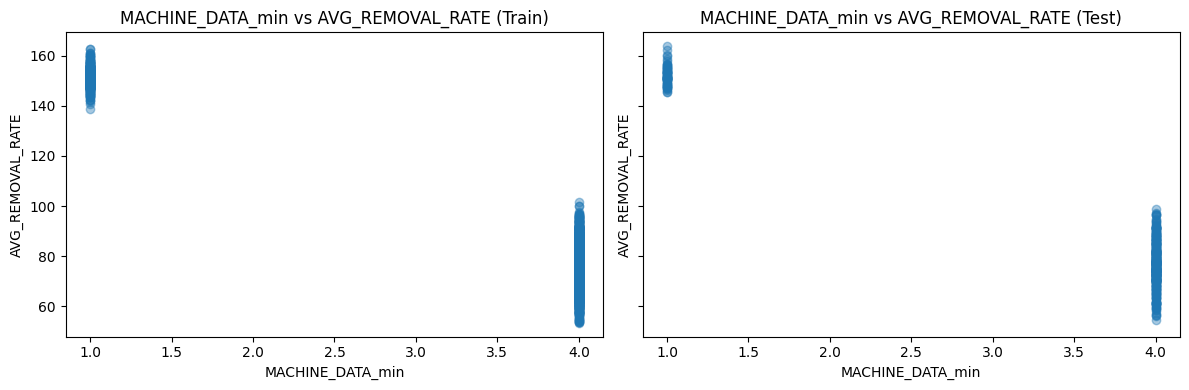

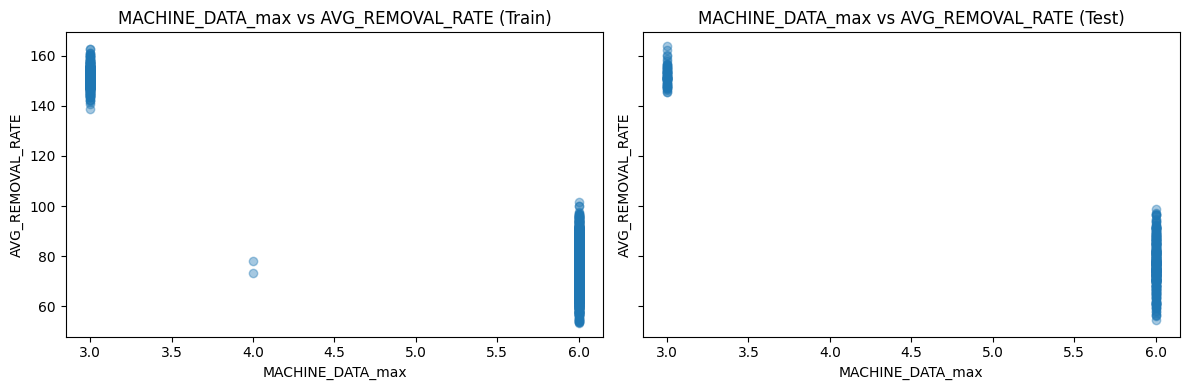

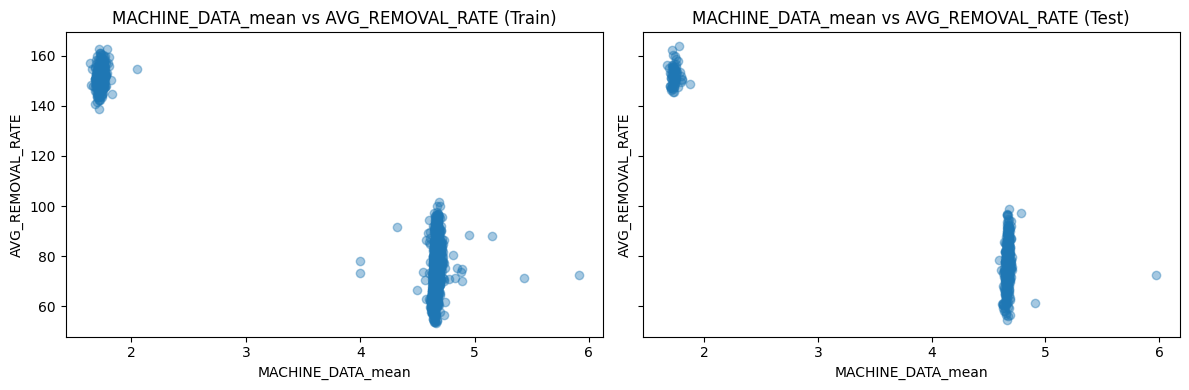

In [18]:
import matplotlib.pyplot as plt

top_features = corr.drop("AVG_REMOVAL_RATE").abs().sort_values(ascending=False).head(3).index.tolist()

for col in top_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    axes[0].scatter(df_eda_train[col], df_eda_train["AVG_REMOVAL_RATE"], alpha=0.4)
    axes[0].set_title(f"{col} vs AVG_REMOVAL_RATE (Train)")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("AVG_REMOVAL_RATE")

    axes[1].scatter(df_eda_test[col], df_eda_test["AVG_REMOVAL_RATE"], alpha=0.4)
    axes[1].set_title(f"{col} vs AVG_REMOVAL_RATE (Test)")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("AVG_REMOVAL_RATE")

    plt.tight_layout()
    plt.show()



In [19]:
usage_cols = [col for col in df_eda_train.columns if "USAGE" in col and col.endswith("_mean")]

usage_corr = df_eda_train[usage_cols + ["AVG_REMOVAL_RATE"]].corr()["AVG_REMOVAL_RATE"].sort_values(ascending=False)
display(usage_corr)

usage_cols_test = [col for col in df_eda_test.columns if "USAGE" in col and col.endswith("_mean")]

usage_corr_test = df_eda_test[usage_cols_test + ["AVG_REMOVAL_RATE"]].corr()["AVG_REMOVAL_RATE"].sort_values(ascending=False)
display(usage_corr_test)


AVG_REMOVAL_RATE                 1.000000
USAGE_OF_DRESSER_TABLE_mean      0.113160
USAGE_OF_BACKING_FILM_mean       0.074085
USAGE_OF_DRESSER_mean           -0.031004
USAGE_OF_POLISHING_TABLE_mean   -0.115623
Name: AVG_REMOVAL_RATE, dtype: float64

AVG_REMOVAL_RATE                 1.000000
USAGE_OF_DRESSER_TABLE_mean      0.129889
USAGE_OF_BACKING_FILM_mean       0.089278
USAGE_OF_DRESSER_mean            0.023261
USAGE_OF_POLISHING_TABLE_mean   -0.118254
Name: AVG_REMOVAL_RATE, dtype: float64

## 2.3 探索性分析與製程診斷

針對 training 與 testing data 進行 EDA，觀察製程變數、耗材使用狀態與材料去除率 `AVG_REMOVAL_RATE` 之間的關係，並進一步提出可能的製程退化或設備健康狀態變化假設。

在進行後續分析前，先根據單一 wafer-stage 的 time-series 趨勢圖與相關性分析，檢查變數間是否存在明顯冗餘。結果顯示，部分耗材使用量與 air bag pressure 類變數彼此高度相關，因此後續分析保留代表性變數，以降低特徵冗餘並提升解釋性。

在 training data 中，`AVG_REMOVAL_RATE` 在不同 `STAGE` 與 `CHAMBER` 下皆呈現明顯差異，其中 `STAGE A` 與 `CHAMBER 1` 對應較高的去除率區間，而 `STAGE B` 與 `CHAMBER 4` 則較集中於低區間。相關分析進一步顯示，`MACHINE_DATA` 類特徵與 `AVG_REMOVAL_RATE` 關聯明顯，且散點圖中樣本可被區分為不同群組，表示設備狀態訊號可能反映不同製程模式或操作條件。

在 testing data 中，`STAGE`、`CHAMBER` 與 `MACHINE_DATA` 相關特徵也呈現與 training data 類似的趨勢，顯示上述關係具有一定穩定性。此外，耗材使用相關特徵中，`USAGE_OF_DRESSER_TABLE_mean` 與 `USAGE_OF_BACKING_FILM_mean` 與 `AVG_REMOVAL_RATE` 呈現正相關，而 `USAGE_OF_POLISHING_TABLE_mean` 則呈現輕微負相關，表示耗材使用狀態可能與 CMP 製程去除效率變化有關。

綜合而言，材料去除率的變化可能受到製程階段、設備腔體與設備狀態特徵的共同影響，而部分耗材使用變數則可能反映耗材磨耗與潛在製程退化現象。這些結果可作為後續 2.4 特徵工程與模型建構的重要依據。


In [21]:
import pandas as pd

group_cols = ["WAFER_ID", "STAGE"]
exclude_cols = ["TIMESTAMP", "WAFER_ID"]

# 依欄位名稱分群
usage_cols = [col for col in df_sensor_reduced.columns if col.startswith("USAGE_")]
slurry_cols = [col for col in df_sensor_reduced.columns if col.startswith("SLURRY_FLOW_LINE_")]
pressure_cols = [col for col in df_sensor_reduced.columns if "PRESSURE" in col]
rotation_cols = [col for col in df_sensor_reduced.columns if "ROTATION" in col]

def build_features(df_sensor_input):
    df_temp = df_sensor_input.copy()

    numeric_cols = df_temp.select_dtypes(include="number").columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

    # 1. 原本的統計特徵
    df_base = df_temp.groupby(group_cols)[numeric_cols].agg(["mean", "std", "max", "min"])
    df_base.columns = [f"{col}_{stat}" for col, stat in df_base.columns]
    df_base = df_base.reset_index()

    # 2. 客製化特徵
    custom_feature_frames = []

    # usage 類：起點、終點、變化量
    available_usage = [col for col in usage_cols if col in df_temp.columns]
    if available_usage:
        usage_start = df_temp.groupby(group_cols)[available_usage].first().add_suffix("_start")
        usage_end = df_temp.groupby(group_cols)[available_usage].last().add_suffix("_end")
        usage_delta = (
            df_temp.groupby(group_cols)[available_usage].last()
            - df_temp.groupby(group_cols)[available_usage].first()
        )
        usage_delta = usage_delta.add_suffix("_delta")

        usage_features = pd.concat([usage_start, usage_end, usage_delta], axis=1).reset_index()
        custom_feature_frames.append(usage_features)

    # slurry 類：啟用比例
    available_slurry = [col for col in slurry_cols if col in df_temp.columns]
    if available_slurry:
        slurry_active_ratio = df_temp.groupby(group_cols)[available_slurry].apply(
            lambda x: (x > 0).mean()
        )
        slurry_active_ratio = slurry_active_ratio.add_suffix("_active_ratio").reset_index()
        custom_feature_frames.append(slurry_active_ratio)

    # rotation 類：啟用比例
    available_rotation = [col for col in rotation_cols if col in df_temp.columns]
    if available_rotation:
        rotation_active_ratio = df_temp.groupby(group_cols)[available_rotation].apply(
            lambda x: (x > 0).mean()
        )
        rotation_active_ratio = rotation_active_ratio.add_suffix("_active_ratio").reset_index()
        custom_feature_frames.append(rotation_active_ratio)

    # DRESSING_WATER_STATUS：若存在，補啟用比例與總和
    if "DRESSING_WATER_STATUS" in df_temp.columns:
        dressing_features = df_temp.groupby(group_cols)["DRESSING_WATER_STATUS"].agg(["mean", "sum"])
        dressing_features.columns = ["DRESSING_WATER_STATUS_active_ratio", "DRESSING_WATER_STATUS_total_on"]
        dressing_features = dressing_features.reset_index()
        custom_feature_frames.append(dressing_features)

    # MACHINE_DATA：模式數與最常見值
    if "MACHINE_DATA" in df_temp.columns:
        machine_features = df_temp.groupby(group_cols)["MACHINE_DATA"].agg(
            MACHINE_DATA_nunique="nunique",
            MACHINE_DATA_mode=lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
        ).reset_index()
        custom_feature_frames.append(machine_features)

    # 3. 合併所有客製特徵
    df_features = df_base.copy()
    for extra_df in custom_feature_frames:
        df_features = pd.merge(df_features, extra_df, on=group_cols, how="left")

    # 4. chamber 對應
    df_chamber_map = (
        df_temp.groupby(group_cols)["CHAMBER"]
        .first()
        .reset_index()
    )

    return df_features, df_chamber_map


In [22]:
# training features
df_sensor_agg, df_chamber_map = build_features(df_sensor_reduced)

df_model = pd.merge(
    df_target_no_outlier,
    df_sensor_agg,
    on=["WAFER_ID", "STAGE"],
    how="inner"
)

df_model = pd.merge(
    df_model,
    df_chamber_map,
    on=["WAFER_ID", "STAGE"],
    how="left"
)

print("df_model shape:", df_model.shape)
display(df_model.head())




df_model shape: (1977, 86)


,WAFER_ID,STAGE,AVG_REMOVAL_RATE,MACHINE_DATA_mean,MACHINE_DATA_std,MACHINE_DATA_max,MACHINE_DATA_min,USAGE_OF_BACKING_FILM_mean,USAGE_OF_BACKING_FILM_std,USAGE_OF_BACKING_FILM_max,...,SLURRY_FLOW_LINE_B_active_ratio,SLURRY_FLOW_LINE_C_active_ratio,WAFER_ROTATION_active_ratio,STAGE_ROTATION_active_ratio,HEAD_ROTATION_active_ratio,DRESSING_WATER_STATUS_active_ratio,DRESSING_WATER_STATUS_total_on,MACHINE_DATA_nunique,MACHINE_DATA_mode,CHAMBER
0,-4224160600,A,61.65480,4.741935,0.856275,6,4,9326.319648,3.701723,9332.500000,...,0.994135,0.788856,0.319648,0.387097,1.0,0.574780,196.0,3,4,4
1,-4224160584,B,75.86415,4.652422,0.799277,6,4,9285.838082,3.762806,9292.500000,...,0.997151,0.817664,0.433048,0.330484,1.0,0.116809,41.0,3,4,4
2,-4224160580,B,71.90700,4.662857,0.801534,6,4,9292.469048,3.766748,9299.166667,...,0.994286,0.825714,0.434286,0.325714,1.0,0.137143,48.0,3,4,4
3,-4113511818,A,65.02230,4.648876,0.799841,6,4,9259.550562,3.882177,9266.666667,...,0.997191,0.823034,0.426966,0.323034,1.0,1.000000,356.0,3,4,4
4,-4113511814,A,58.27905,4.644068,0.798640,6,4,9436.104049,2.658880,9438.333333,...,0.564972,0.440678,0.432203,0.316384,1.0,0.121469,43.0,3,4,4


In [23]:
# testing features
df_test_sensor_agg, df_test_chamber_map = build_features(df_test_sensor_reduced)

df_test_model = pd.merge(
    df_test_target_clean,
    df_test_sensor_agg,
    on=["WAFER_ID", "STAGE"],
    how="inner"
)

df_test_model = pd.merge(
    df_test_model,
    df_test_chamber_map,
    on=["WAFER_ID", "STAGE"],
    how="left"
)

print("df_test_model shape:", df_test_model.shape)
display(df_test_model.head())


df_test_model shape: (424, 86)


,WAFER_ID,STAGE,AVG_REMOVAL_RATE,MACHINE_DATA_mean,MACHINE_DATA_std,MACHINE_DATA_max,MACHINE_DATA_min,USAGE_OF_BACKING_FILM_mean,USAGE_OF_BACKING_FILM_std,USAGE_OF_BACKING_FILM_max,...,SLURRY_FLOW_LINE_B_active_ratio,SLURRY_FLOW_LINE_C_active_ratio,WAFER_ROTATION_active_ratio,STAGE_ROTATION_active_ratio,HEAD_ROTATION_active_ratio,DRESSING_WATER_STATUS_active_ratio,DRESSING_WATER_STATUS_total_on,MACHINE_DATA_nunique,MACHINE_DATA_mode,CHAMBER
0,-4224160678,B,66.9813,4.648876,0.799841,6,4,9526.132959,3.834909,9533.333333,...,0.994382,0.834270,0.429775,0.308989,1.0,0.558989,199.0,3,4,4
1,-4224160592,A,56.1786,4.667630,0.803574,6,4,9332.545761,3.690949,9339.166667,...,0.994220,0.812139,0.398844,0.387283,1.0,0.566474,196.0,3,4,4
2,-887170152,B,64.3881,4.655977,0.797300,6,4,9424.735180,3.707760,9430.833333,...,0.994169,0.787172,0.224490,0.268222,1.0,0.166181,57.0,3,4,4
3,373446766,A,153.2610,1.693950,0.844477,3,1,9356.666667,0.000000,9356.666667,...,0.000000,0.000000,0.000000,0.000000,1.0,0.462633,130.0,3,1,1
4,-4224160686,A,57.2523,4.654286,0.799657,6,4,9614.945238,3.747940,9621.666667,...,0.994286,0.825714,0.434286,0.334286,1.0,0.568571,199.0,3,4,4


In [24]:
X = df_model.drop(columns=["AVG_REMOVAL_RATE", "WAFER_ID"])
y = df_model["AVG_REMOVAL_RATE"]

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (1977, 84)
y shape: (1977,)


,STAGE,MACHINE_DATA_mean,MACHINE_DATA_std,MACHINE_DATA_max,MACHINE_DATA_min,USAGE_OF_BACKING_FILM_mean,USAGE_OF_BACKING_FILM_std,USAGE_OF_BACKING_FILM_max,USAGE_OF_BACKING_FILM_min,USAGE_OF_DRESSER_mean,...,SLURRY_FLOW_LINE_B_active_ratio,SLURRY_FLOW_LINE_C_active_ratio,WAFER_ROTATION_active_ratio,STAGE_ROTATION_active_ratio,HEAD_ROTATION_active_ratio,DRESSING_WATER_STATUS_active_ratio,DRESSING_WATER_STATUS_total_on,MACHINE_DATA_nunique,MACHINE_DATA_mode,CHAMBER
0,A,4.741935,0.856275,6,4,9326.319648,3.701723,9332.500000,9320.000000,534.989682,...,0.994135,0.788856,0.319648,0.387097,1.0,0.574780,196.0,3,4,4
1,B,4.652422,0.799277,6,4,9285.838082,3.762806,9292.500000,9280.000000,533.133903,...,0.997151,0.817664,0.433048,0.330484,1.0,0.116809,41.0,3,4,4
2,B,4.662857,0.801534,6,4,9292.469048,3.766748,9299.166667,9286.666667,533.501587,...,0.994286,0.825714,0.434286,0.325714,1.0,0.137143,48.0,3,4,4
3,A,4.648876,0.799841,6,4,9259.550562,3.882177,9266.666667,9253.333333,532.019351,...,0.997191,0.823034,0.426966,0.323034,1.0,1.000000,356.0,3,4,4
4,A,4.644068,0.798640,6,4,9436.104049,2.658880,9438.333333,9430.833333,541.851852,...,0.564972,0.440678,0.432203,0.316384,1.0,0.121469,43.0,3,4,4


In [30]:
import pandas as pd

from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# 建模資料
X = df_model.drop(columns=["AVG_REMOVAL_RATE", "WAFER_ID"])
y = df_model["AVG_REMOVAL_RATE"]

# 類別 / 數值欄位
categorical_features = ["STAGE", "CHAMBER"]
numeric_features = [col for col in X.columns if col not in categorical_features]

# 前處理
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Nested CV：外層評估、內層調參
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 評估指標
scoring = {
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
}

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))



X shape: (1977, 84)
y shape: (1977,)
Number of numeric features: 82
Number of categorical features: 2


In [31]:
from sklearn.linear_model import Ridge
from skopt import BayesSearchCV
from skopt.space import Real

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

search_spaces_ridge = {
    "model__alpha": Real(1e-4, 1e3, prior="log-uniform")
}

ridge_search = BayesSearchCV(
    estimator=ridge_pipeline,
    search_spaces=search_spaces_ridge,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=inner_cv,
    n_jobs=-1,
    random_state=42
)

cv_results_ridge_nested = cross_validate(
    ridge_search,
    X,
    y,
    cv=outer_cv,
    scoring=scoring,
    return_train_score=False
)

print("Nested CV Ridge Results")
print(f"MAE: {-cv_results_ridge_nested['test_mae'].mean():.4f} ± {cv_results_ridge_nested['test_mae'].std():.4f}")
print(f"MSE: {-cv_results_ridge_nested['test_mse'].mean():.4f} ± {cv_results_ridge_nested['test_mse'].std():.4f}")

ridge_fold_results = pd.DataFrame({
    "Fold": range(1, len(cv_results_ridge_nested["test_mae"]) + 1),
    "MAE": -cv_results_ridge_nested["test_mae"],
    "MSE": -cv_results_ridge_nested["test_mse"]
})

print("\nPer-fold results:")
display(ridge_fold_results)



Nested CV Ridge Results
MAE: 4.2702 ± 0.1381
MSE: 30.5291 ± 1.7366

Per-fold results:


,Fold,MAE,MSE
0,1,4.307766,29.981395
1,2,4.247095,29.530271
2,3,4.191634,30.453386
3,4,4.095857,28.844289
4,5,4.508550,33.836122


In [33]:
from sklearn.ensemble import RandomForestRegressor
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

search_spaces_rf = {
    "model__n_estimators": Integer(100, 400),
    "model__max_depth": Integer(3, 20),
    "model__min_samples_split": Integer(2, 20),
    "model__min_samples_leaf": Integer(1, 10),
    "model__max_features": Categorical(["sqrt", "log2", None])
}

rf_search = BayesSearchCV(
    estimator=rf_pipeline,
    search_spaces=search_spaces_rf,
    n_iter=20,
    scoring="neg_mean_squared_error",
    cv=inner_cv,
    n_jobs=-1,
    random_state=42
)

cv_results_rf_nested = cross_validate(
    rf_search,
    X,
    y,
    cv=outer_cv,
    scoring=scoring,
    return_train_score=False
)

print("Nested CV Random Forest Results")
print(f"MAE: {-cv_results_rf_nested['test_mae'].mean():.4f} ± {cv_results_rf_nested['test_mae'].std():.4f}")
print(f"MSE: {-cv_results_rf_nested['test_mse'].mean():.4f} ± {cv_results_rf_nested['test_mse'].std():.4f}")

rf_fold_results = pd.DataFrame({
    "Fold": range(1, len(cv_results_rf_nested["test_mae"]) + 1),
    "MAE": -cv_results_rf_nested["test_mae"],
    "MSE": -cv_results_rf_nested["test_mse"]
})

print("\nPer-fold results:")
display(rf_fold_results)


c:\Users\allen\AppData\Local\Programs\Python\Python314\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(20), None, np.int64(1), np.int64(2), np.int64(400)] before, using random point [np.int64(6), 'sqrt', np.int64(4), np.int64(7), np.int64(141)]
  warnings.warn(
c:\Users\allen\AppData\Local\Programs\Python\Python314\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(20), np.str_('sqrt'), np.int64(1), np.int64(2), np.int64(400)] before, using random point [np.int64(9), None, np.int64(1), np.int64(16), np.int64(374)]
  warnings.warn(
c:\Users\allen\AppData\Local\Programs\Python\Python314\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(20), None, np.int64(1), np.int64(2), np.int64(400)] before, using random point [np.int64(4), None, np.int64(1), np.int64(12), np.int64(167)]
  warnings.warn

Nested CV Random Forest Results
MAE: 2.6509 ± 0.1626
MSE: 11.9017 ± 1.4516

Per-fold results:


,Fold,MAE,MSE
0,1,2.597359,11.086508
1,2,2.684897,12.397750
2,3,2.533840,11.259451
3,4,2.489885,10.290570
4,5,2.948501,14.474073


In [35]:
results_24 = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        f"{-cv_results_ridge_nested['test_mae'].mean():.4f} ± {cv_results_ridge_nested['test_mae'].std():.4f}",
        f"{-cv_results_rf_nested['test_mae'].mean():.4f} ± {cv_results_rf_nested['test_mae'].std():.4f}"
    ],
    "MSE": [
        f"{-cv_results_ridge_nested['test_mse'].mean():.4f} ± {cv_results_ridge_nested['test_mse'].std():.4f}",
        f"{-cv_results_rf_nested['test_mse'].mean():.4f} ± {cv_results_rf_nested['test_mse'].std():.4f}"
    ],
})

results_24


,Model,MAE,MSE
0,Linear Regression,4.2702 ± 0.1381,30.5291 ± 1.7366
1,Random Forest,2.6509 ± 0.1626,11.9017 ± 1.4516


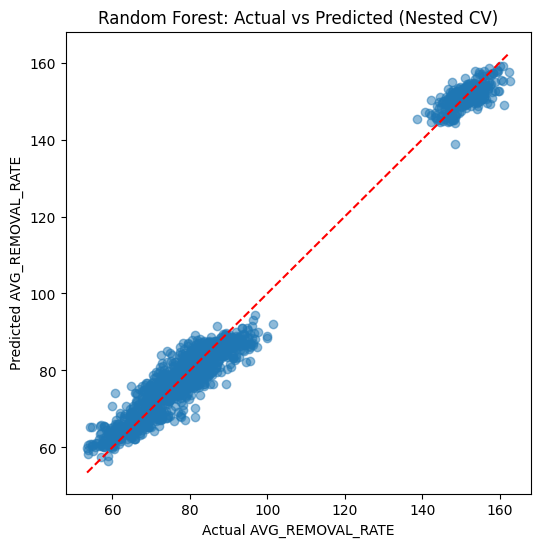

In [36]:
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt

# 用 outer_cv 對 nested RF 產生 out-of-fold prediction
y_pred_rf = cross_val_predict(rf_search, X, y, cv=outer_cv, n_jobs=-1)

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred_rf, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--")
plt.xlabel("Actual AVG_REMOVAL_RATE")
plt.ylabel("Predicted AVG_REMOVAL_RATE")
plt.title("Random Forest: Actual vs Predicted (Nested CV)")
plt.show()


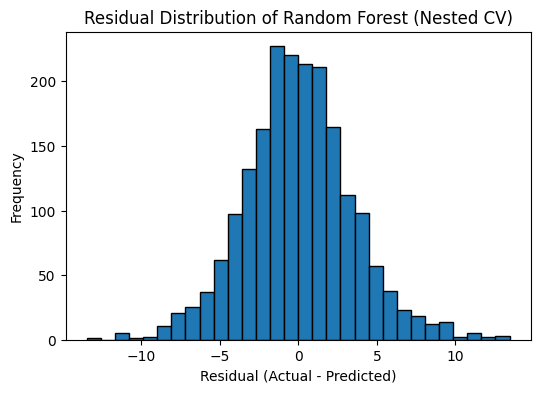

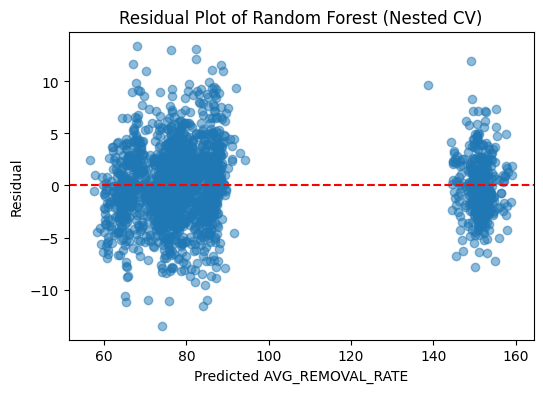

In [37]:
residuals_rf = y - y_pred_rf

plt.figure(figsize=(6, 4))
plt.hist(residuals_rf, bins=30, edgecolor="black")
plt.title("Residual Distribution of Random Forest (Nested CV)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_rf, residuals_rf, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted AVG_REMOVAL_RATE")
plt.ylabel("Residual")
plt.title("Residual Plot of Random Forest (Nested CV)")
plt.show()


In [38]:
X_train = df_model.drop(columns=["AVG_REMOVAL_RATE", "WAFER_ID"])
y_train = df_model["AVG_REMOVAL_RATE"]

X_test = df_test_model.drop(columns=["AVG_REMOVAL_RATE", "WAFER_ID"])
y_test = df_test_model["AVG_REMOVAL_RATE"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (1977, 84)
y_train shape: (1977,)
X_test shape: (424, 84)
y_test shape: (424,)


In [39]:
rf_search.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,search_spaces,"{'model__max_depth': Integer(low=3...m='normalize'), 'model__max_features': Categorical(c...), prior=None), 'model__min_samples_leaf': Integer(low=1...m='normalize'), 'model__min_samples_split': Integer(low=2...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,20
,scoring,'neg_mean_squared_error'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,KFold(n_split... shuffle=True)


In [40]:
y_test_pred = rf_search.predict(X_test)


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Random Forest Test Results")
print("MAE:", test_mae)
print("MSE:", test_mse)


Random Forest Test Results
MAE: 2.457528013438351
MSE: 10.858222669085464


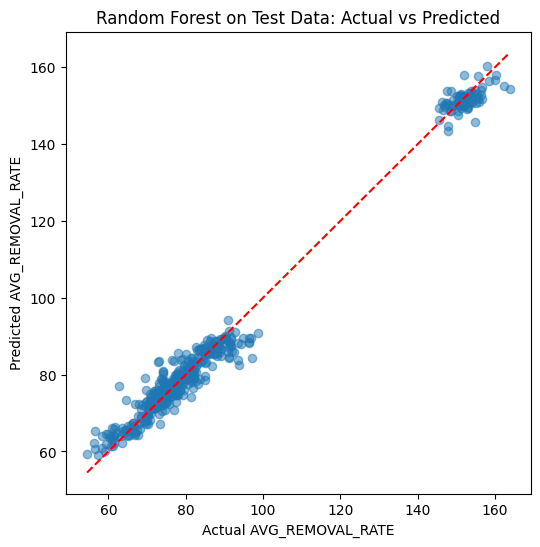

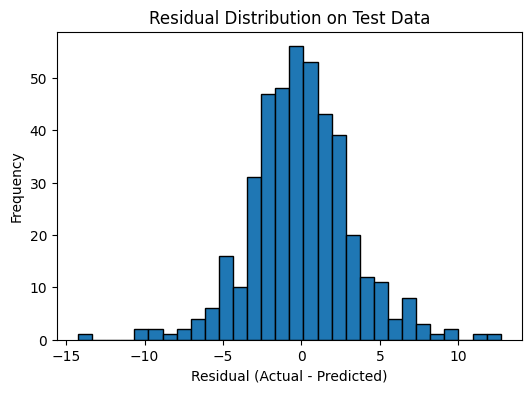

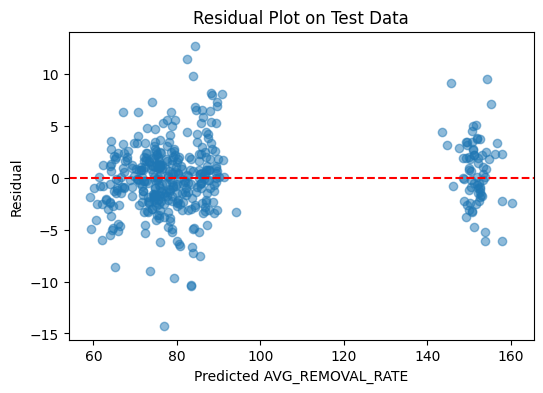

In [42]:
import matplotlib.pyplot as plt

# Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Actual AVG_REMOVAL_RATE")
plt.ylabel("Predicted AVG_REMOVAL_RATE")
plt.title("Random Forest on Test Data: Actual vs Predicted")
plt.show()

# Residual
test_residuals = y_test - y_test_pred

plt.figure(figsize=(6, 4))
plt.hist(test_residuals, bins=30, edgecolor="black")
plt.title("Residual Distribution on Test Data")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(y_test_pred, test_residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted AVG_REMOVAL_RATE")
plt.ylabel("Residual")
plt.title("Residual Plot on Test Data")
plt.show()


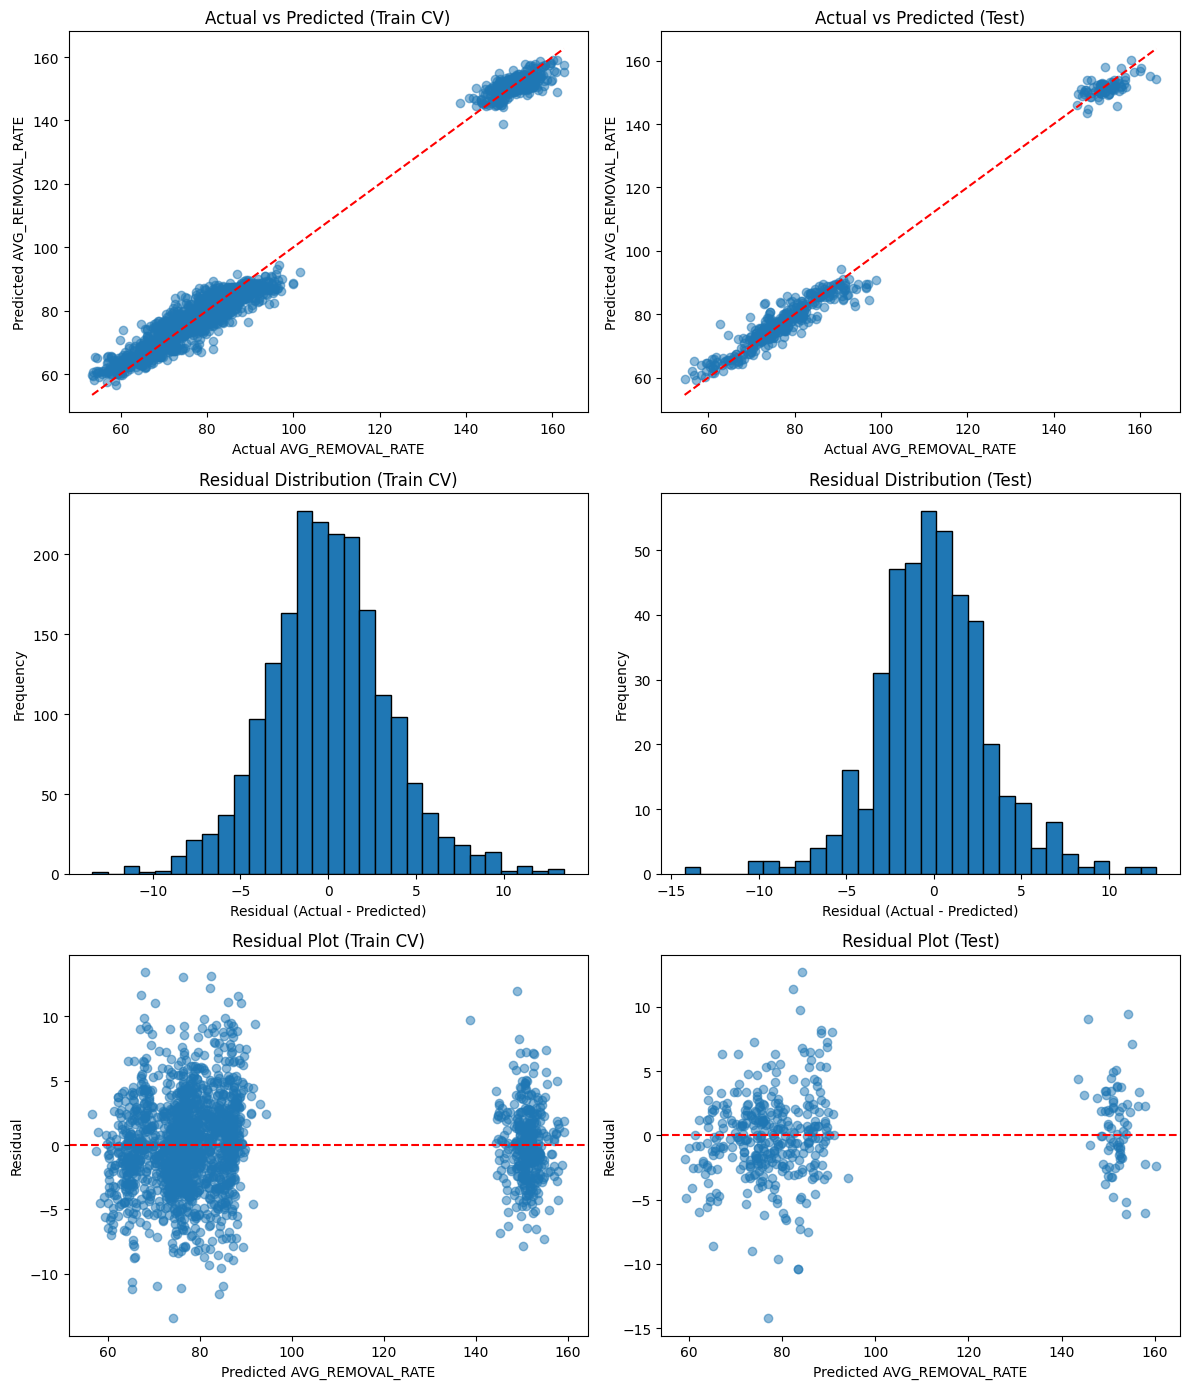

,Dataset,MAE_mean,MAE_std,MSE_mean,MSE_std
0,Training CV,2.650896,0.162615,11.901671,1.451615
1,Testing,2.457528,NaN,10.858223,NaN


In [43]:
import matplotlib.pyplot as plt
import numpy as np

# training / testing residuals
train_residuals = y_train - y_pred_rf
test_residuals = y_test - y_test_pred

fig, axes = plt.subplots(3, 2, figsize=(12, 14))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_train, y_pred_rf, alpha=0.5)
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], color="red", linestyle="--")
axes[0, 0].set_title("Actual vs Predicted (Train CV)")
axes[0, 0].set_xlabel("Actual AVG_REMOVAL_RATE")
axes[0, 0].set_ylabel("Predicted AVG_REMOVAL_RATE")

axes[0, 1].scatter(y_test, y_test_pred, alpha=0.5)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
axes[0, 1].set_title("Actual vs Predicted (Test)")
axes[0, 1].set_xlabel("Actual AVG_REMOVAL_RATE")
axes[0, 1].set_ylabel("Predicted AVG_REMOVAL_RATE")

# 2. Residual Distribution
axes[1, 0].hist(train_residuals, bins=30, edgecolor="black")
axes[1, 0].set_title("Residual Distribution (Train CV)")
axes[1, 0].set_xlabel("Residual (Actual - Predicted)")
axes[1, 0].set_ylabel("Frequency")

axes[1, 1].hist(test_residuals, bins=30, edgecolor="black")
axes[1, 1].set_title("Residual Distribution (Test)")
axes[1, 1].set_xlabel("Residual (Actual - Predicted)")
axes[1, 1].set_ylabel("Frequency")

# 3. Residual Plot
axes[2, 0].scatter(y_pred_rf, train_residuals, alpha=0.5)
axes[2, 0].axhline(0, color="red", linestyle="--")
axes[2, 0].set_title("Residual Plot (Train CV)")
axes[2, 0].set_xlabel("Predicted AVG_REMOVAL_RATE")
axes[2, 0].set_ylabel("Residual")

axes[2, 1].scatter(y_test_pred, test_residuals, alpha=0.5)
axes[2, 1].axhline(0, color="red", linestyle="--")
axes[2, 1].set_title("Residual Plot (Test)")
axes[2, 1].set_xlabel("Predicted AVG_REMOVAL_RATE")
axes[2, 1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

results_compare = pd.DataFrame({
    "Dataset": ["Training CV", "Testing"],
    "MAE_mean": [
        -cv_results_rf_nested["test_mae"].mean(),
        test_mae
    ],
    "MAE_std": [
        cv_results_rf_nested["test_mae"].std(),
        np.nan
    ],
    "MSE_mean": [
        -cv_results_rf_nested["test_mse"].mean(),
        test_mse
    ],
    "MSE_std": [
        cv_results_rf_nested["test_mse"].std(),
        np.nan
    ]
})

results_compare


## 2.4 製程效能預測模型建構

目標是以材料去除率 `AVG_REMOVAL_RATE` 為預測目標，建立 CMP 製程效能預測模型。由於原始 sensor data 為 time-series 結構，無法直接與 wafer-level 的目標資料對應，因此先依 `WAFER_ID` 與 `STAGE` 將感測資料聚合為 wafer-level 特徵，再與清理後的 target table 合併，作為後續回歸模型的輸入資料。為確保模型泛化能力，本研究除使用 training data 建模外，亦進一步以 testing data 進行獨立驗證。

### 特徵挑選與特徵工程

根據前述 EDA 結果，`AVG_REMOVAL_RATE` 與 `STAGE`、`CHAMBER`、`MACHINE_DATA` 類特徵，以及部分耗材使用與製程狀態變數具有明顯關聯，因此將這些資訊納入模型。`WAFER_ID` 僅作為識別欄位，不具預測意義，因此不納入模型特徵。

在特徵工程方面，先以 `WAFER_ID` 與 `STAGE` 為單位，將感測資料轉換為 wafer-level 聚合特徵，保留各變數的 `mean`、`std`、`max` 與 `min`。另外，也依欄位意義補充部分客製化特徵，例如耗材使用量變化、狀態變數啟用比例與設備狀態模式數等。對於高度相關的變數群，則保留代表性變數以降低特徵冗餘。類別特徵以 one-hot encoding 處理，數值特徵則採用中位數補值；training 與 testing data 均採用一致流程。

### 模型選擇理由

以線性模型作為 baseline，比較較簡單假設下的預測能力；再以 `RandomForestRegressor` 作為主要模型。由於資料呈現明顯群組結構與非線性關係，且不同 `STAGE` 與 `CHAMBER` 的去除率分布存在系統性差異，因此 Random Forest 較能捕捉此類複雜關係。

### 訓練與驗證方式

模型訓練主要使用 training data。線性模型與 Random Forest 皆採用 nested cross validation，在外層進行模型評估、內層以 Bayesian optimization 搜尋較佳超參數組合，以降低模型選擇偏誤並提供較保守的泛化能力估計。之後再以獨立 testing data 驗證模型在未見資料上的泛化能力。評估指標包括：

- `MAE`：衡量平均絕對誤差
- `MSE`：衡量平方誤差大小

### 模型結果與分析

模型比較結果顯示，線性模型與 Random Forest 均具有一定預測能力，但 Random Forest 的整體表現較佳，表示資料中的非線性關係與群組結構確實對預測結果具有重要影響。

以 Random Forest 為例，nested CV 在 training data 上提供了較保守的模型評估，而其所選出的模型在 testing data 上仍維持較小的 MSE，表示該方法有助於提升模型泛化能力。從實際值與預測值散點圖及殘差圖亦可看出，模型預測結果與實際值大致一致，且未出現明顯系統性偏差。

In [45]:
# 用 training data fit 最終模型
rf_search.fit(X_train, y_train)

# 取最佳 pipeline
best_rf_pipeline = rf_search.best_estimator_

# 取得前處理後特徵名稱
feature_names = best_rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

# 取得 feature importance
importances = best_rf_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(feature_importance_df.head(20))


,Feature,Importance
84,cat__CHAMBER_1,0.781836
0,num__MACHINE_DATA_mean,0.055294
2,num__MACHINE_DATA_max,0.027861
85,cat__CHAMBER_4,0.025545
81,num__MACHINE_DATA_mode,0.025527
3,num__MACHINE_DATA_min,0.013940
19,num__USAGE_OF_DRESSER_TABLE_min,0.006084
16,num__USAGE_OF_DRESSER_TABLE_mean,0.006081
67,num__USAGE_OF_DRESSER_TABLE_end,0.005829
83,cat__STAGE_B,0.005802


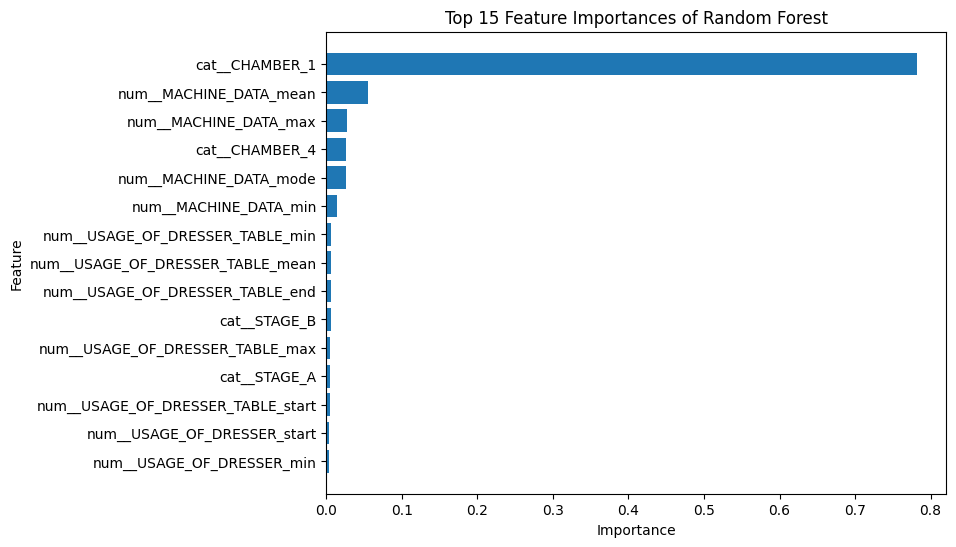

In [46]:
import matplotlib.pyplot as plt

top_n = 15
top_features_df = feature_importance_df.head(top_n).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features_df["Feature"], top_features_df["Importance"])
plt.title("Top 15 Feature Importances of Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [47]:
usage_importance_df = feature_importance_df[
    feature_importance_df["Feature"].str.contains("USAGE", case=False, na=False)
]

display(usage_importance_df.head(20))


,Feature,Importance
19,num__USAGE_OF_DRESSER_TABLE_min,0.006084
16,num__USAGE_OF_DRESSER_TABLE_mean,0.006081
67,num__USAGE_OF_DRESSER_TABLE_end,0.005829
18,num__USAGE_OF_DRESSER_TABLE_max,0.005294
63,num__USAGE_OF_DRESSER_TABLE_start,0.004837
61,num__USAGE_OF_DRESSER_start,0.003263
11,num__USAGE_OF_DRESSER_min,0.003116
8,num__USAGE_OF_DRESSER_mean,0.002876
65,num__USAGE_OF_DRESSER_end,0.001973
10,num__USAGE_OF_DRESSER_max,0.001935


In [48]:
process_keywords = ["USAGE", "PRESSURE", "ROTATION", "SLURRY", "DRESSING_WATER"]

process_importance_df = feature_importance_df[
    feature_importance_df["Feature"].str.contains("|".join(process_keywords), case=False, na=False)
].sort_values("Importance", ascending=False)

display(process_importance_df.head(20))


,Feature,Importance
19,num__USAGE_OF_DRESSER_TABLE_min,0.006084
16,num__USAGE_OF_DRESSER_TABLE_mean,0.006081
67,num__USAGE_OF_DRESSER_TABLE_end,0.005829
18,num__USAGE_OF_DRESSER_TABLE_max,0.005294
63,num__USAGE_OF_DRESSER_TABLE_start,0.004837
61,num__USAGE_OF_DRESSER_start,0.003263
11,num__USAGE_OF_DRESSER_min,0.003116
8,num__USAGE_OF_DRESSER_mean,0.002876
65,num__USAGE_OF_DRESSER_end,0.001973
10,num__USAGE_OF_DRESSER_max,0.001935


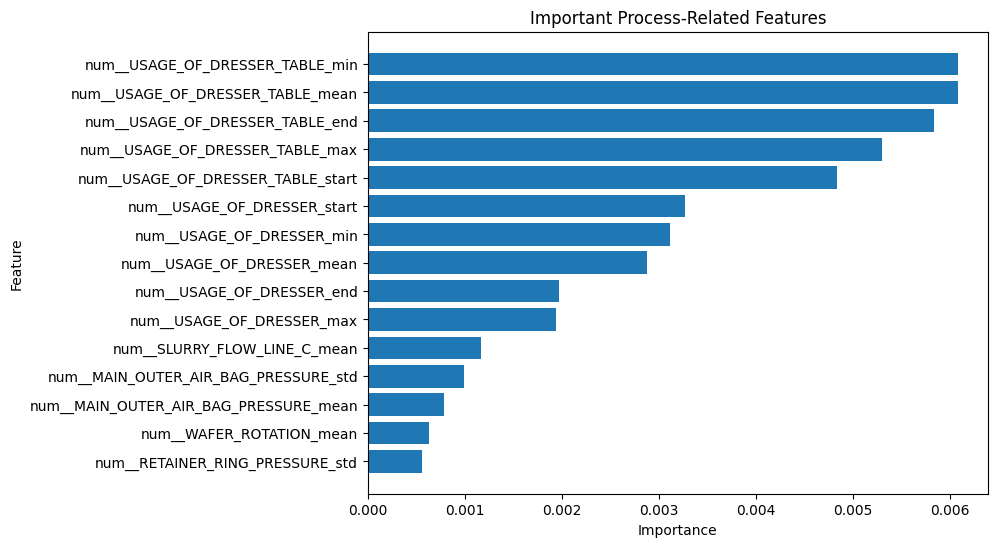

In [49]:
top_process_df = process_importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_process_df["Feature"], top_process_df["Importance"])
plt.title("Important Process-Related Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [50]:
# 取前 3 個最重要的數值特徵來做 train/test 對照
top_numeric_features = [
    f for f in feature_importance_df["Feature"].tolist()
    if f.startswith("num__")
][:3]

# 去掉前綴，還原成 df_model / df_test_model 的欄位名稱
top_numeric_features = [f.replace("num__", "") for f in top_numeric_features]

print("Top numeric features used for train/test comparison:")
print(top_numeric_features)


Top numeric features used for train/test comparison:
['MACHINE_DATA_mean', 'MACHINE_DATA_max', 'MACHINE_DATA_mode']


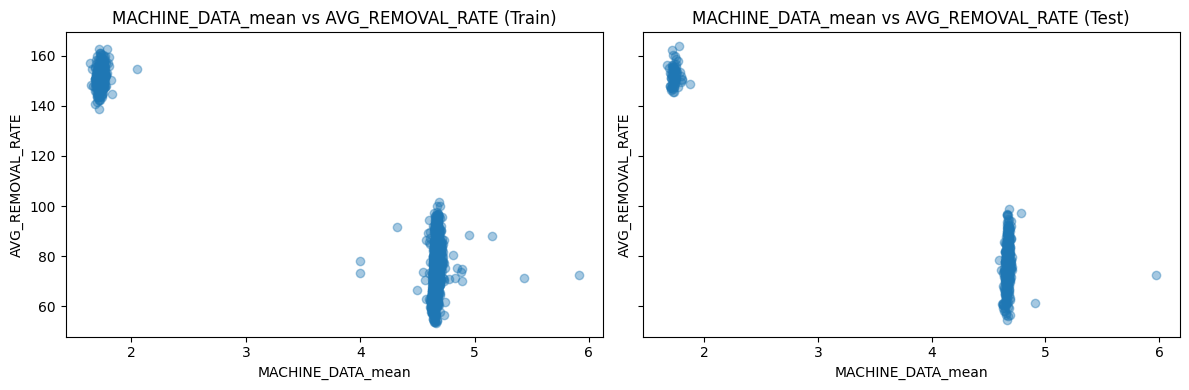

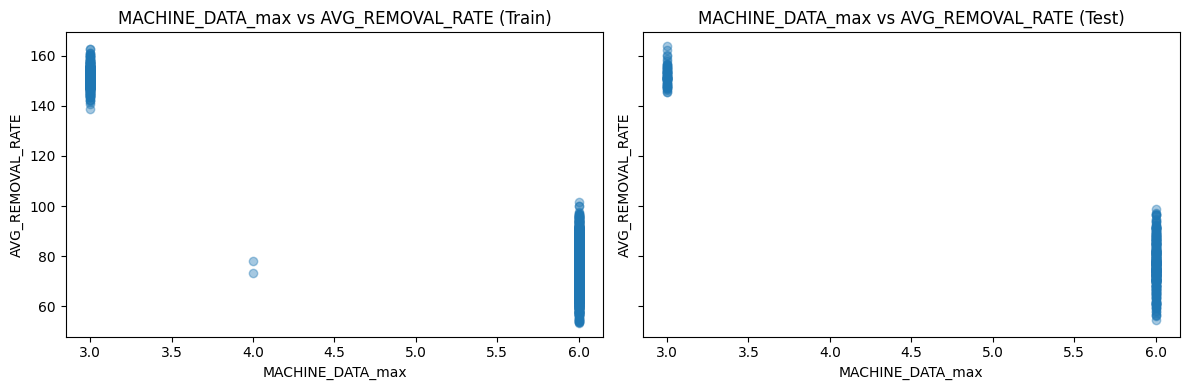

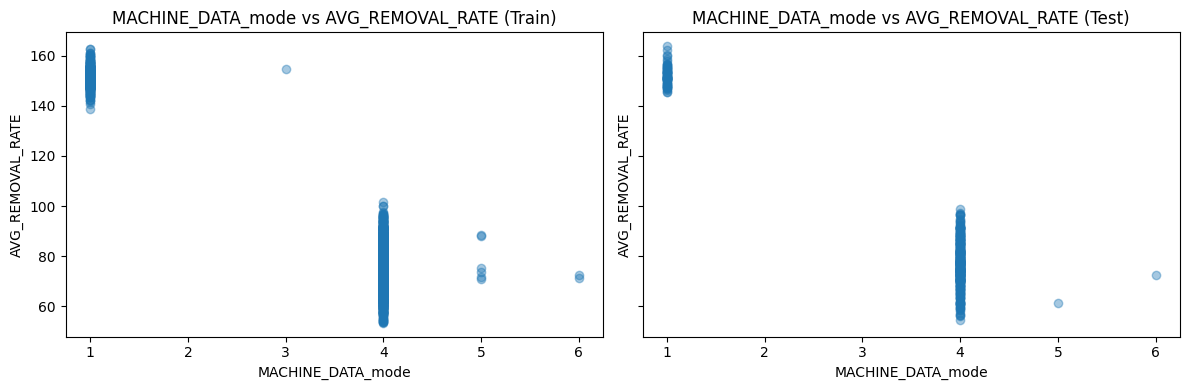

In [51]:
import matplotlib.pyplot as plt

for col in top_numeric_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    axes[0].scatter(df_model[col], df_model["AVG_REMOVAL_RATE"], alpha=0.4)
    axes[0].set_title(f"{col} vs AVG_REMOVAL_RATE (Train)")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("AVG_REMOVAL_RATE")

    axes[1].scatter(df_test_model[col], df_test_model["AVG_REMOVAL_RATE"], alpha=0.4)
    axes[1].set_title(f"{col} vs AVG_REMOVAL_RATE (Test)")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("AVG_REMOVAL_RATE")

    plt.tight_layout()
    plt.show()


In [52]:
usage_cols_train = [col for col in df_model.columns if "USAGE" in col and col.endswith("_mean")]
usage_cols_test = [col for col in df_test_model.columns if "USAGE" in col and col.endswith("_mean")]

usage_corr_train = df_model[usage_cols_train + ["AVG_REMOVAL_RATE"]].corr()["AVG_REMOVAL_RATE"].sort_values(ascending=False)
usage_corr_test = df_test_model[usage_cols_test + ["AVG_REMOVAL_RATE"]].corr()["AVG_REMOVAL_RATE"].sort_values(ascending=False)

print("Usage correlation (Train):")
display(usage_corr_train)

print("Usage correlation (Test):")
display(usage_corr_test)


Usage correlation (Train):


AVG_REMOVAL_RATE                 1.000000
USAGE_OF_DRESSER_TABLE_mean      0.113160
USAGE_OF_BACKING_FILM_mean       0.074085
USAGE_OF_DRESSER_mean           -0.031004
USAGE_OF_POLISHING_TABLE_mean   -0.115623
Name: AVG_REMOVAL_RATE, dtype: float64

Usage correlation (Test):


AVG_REMOVAL_RATE                 1.000000
USAGE_OF_DRESSER_TABLE_mean      0.129889
USAGE_OF_BACKING_FILM_mean       0.089278
USAGE_OF_DRESSER_mean            0.023261
USAGE_OF_POLISHING_TABLE_mean   -0.118254
Name: AVG_REMOVAL_RATE, dtype: float64

## 2.5 模型解釋與健康狀態分析

為解釋 Random Forest 模型的預測結果，以特徵重要度為主要依據，分析哪些變數對材料去除率 `AVG_REMOVAL_RATE` 具有顯著影響，並進一步說明這些變數是否能反映設備或耗材的健康狀態變化。

從整體特徵重要度來看，`cat__CHAMBER_1` 的重要度遠高於其他變數，顯示設備腔體是影響材料去除率的最關鍵因素。`CHAMBER 1` 對應較高的 removal rate，而 `CHAMBER 4` 則對應較低區間，表示不同設備腔體之間存在明顯的系統性差異，可能反映設備健康狀態、校正條件或操作模式的不同。

`MACHINE_DATA_mean`、`MACHINE_DATA_max`、`MACHINE_DATA_min` 與 `MACHINE_DATA_mode` 亦為重要特徵。這些變數在 training 與 testing data 中皆能將樣本區分為不同群組，顯示 `MACHINE_DATA` 較可能反映設備模式、機台狀態或特定製程條件，因此可視為辨識設備狀態的重要訊號。

在耗材使用相關變數方面，`USAGE_OF_DRESSER_TABLE_mean`、`USAGE_OF_DRESSER_TABLE_min`、`USAGE_OF_DRESSER_TABLE_max`，以及 `USAGE_OF_DRESSER_TABLE_start`、`USAGE_OF_DRESSER_TABLE_end` 皆具有較高的重要度；`USAGE_OF_DRESSER_start`、`USAGE_OF_DRESSER_mean` 與 `USAGE_OF_DRESSER_min` 亦有一定影響。再配合相關分析可知，`USAGE_OF_DRESSER_TABLE_mean` 與 `AVG_REMOVAL_RATE` 呈穩定正相關，而 `USAGE_OF_POLISHING_TABLE_mean` 則呈輕微負相關，表示 dresser 類耗材可能與去除率提升有關，而 polishing table 的使用程度則可能與製程退化有關。

`SLURRY_FLOW_LINE_C_mean`、`MAIN_OUTER_AIR_BAG_PRESSURE_std`、`MAIN_OUTER_AIR_BAG_PRESSURE_mean`、`WAFER_ROTATION_mean` 與 `RETAINER_RING_PRESSURE_std` 等特徵亦出現在較重要的變數中，表示材料去除率除了受到設備腔體與耗材使用影響外，也會受到 slurry 供應、壓力控制與轉速條件的共同作用。

材料去除率的變化可反映設備腔體差異、設備狀態訊號與耗材使用程度。`CHAMBER` 可視為設備健康模式差異，`MACHINE_DATA` 類特徵可能反映設備運轉狀態，而 dresser 類耗材特徵則可能反映耗材磨耗與潛在製程退化現象。由於上述關係在 training 與 testing data 中皆呈現一致趨勢，表示 Random Forest 模型不僅具有良好的預測能力，也能提供一定程度的設備健康狀態分析與製程診斷價值。


## 2.6 製程控制與決策建議

根據探索分析、預測模型與特徵重要度結果，可發現 `CHAMBER`、`MACHINE_DATA` 類特徵，以及部分 dresser 與耗材使用變數，對材料去除率 `AVG_REMOVAL_RATE` 具有明顯影響，且相關趨勢在 training 與 testing data 中皆呈現一致性，因此可作為製程控制與設備管理的實務依據。

### 1. 針對不同 CHAMBER 建立分別監控與校正機制

由分析結果可知，不同 `CHAMBER` 的去除率分布存在顯著差異，且 `CHAMBER` 為模型中最重要的特徵，表示設備腔體之間可能存在系統性的製程差異。因此建議針對各 chamber 分別建立基準去除率範圍、獨立監控指標與校正機制，避免以單一整體標準管理所有腔體，進而掩蓋個別設備異常。

### 2. 將 dresser 類耗材使用量納入預防性維護依據

由特徵重要度與相關分析可發現，`USAGE_OF_DRESSER_TABLE` 與 `USAGE_OF_DRESSER` 等變數具有穩定影響力，顯示 dresser 類耗材磨耗可能與材料去除率變化有關。因此建議建立以使用量為基礎的預防性維護策略，將 dresser table、dresser 與 polishing table 等耗材使用狀況納入設備保養排程。

### 3. 強化設備狀態訊號監控

模型結果顯示 `MACHINE_DATA` 類特徵對材料去除率具有顯著影響，且能穩定區分不同去除率群組，表示設備狀態訊號能有效反映不同製程模式或運轉狀態。因此建議針對 `MACHINE_DATA` 類特徵建立長期監控與異常偵測機制，以提前辨識設備狀態變化。

### 4. 對關鍵製程參數設定監控區間

除設備腔體與耗材使用變數外，部分製程條件如 slurry flow、air bag pressure、wafer rotation 與 retainer ring pressure 也對材料去除率具有一定影響。因此建議針對這些關鍵參數建立監控區間與警戒機制，並觀察其與去除率偏差之間的連動關係。

### 5. 將模型導入製程預警與決策支援

由於 Random Forest 在 training 與 testing data 上皆展現良好預測能力，因此可考慮將模型應用於實務上的預警系統。當模型預測結果顯示某批次 wafer 的去除率可能偏離正常範圍時，可提前檢查設備腔體、設備狀態訊號、耗材使用狀況與關鍵製程參數，作為製程工程師的決策支援工具。

